# **BAB 1 - INTRODUCTION**


**Name** : Ma'ruf Habibie Siregar  
**Dashboard Links** : [Dashboard Page 1 Link](https://public.tableau.com/views/StreamWise/Dashboard1?:language=en-US&publish=yes&:sid=&:redirect=auth&:display_count=n&:origin=viz_share_link) and [Dashboard Page 2 Link](https://public.tableau.com/shared/757GHG5ZW?:display_count=n&:origin=viz_share_link)  
This program is created to provide movie recommendations to online streaming platforms regarding which films to buy or rent for screening on their platforms

# **BAB 2 - PROBLEM STATEMENT AND DATASET DESCRIPTION**

## 2.1 Background  
In recent years, the way people enjoy movies has changed. Most people no longer watch television or go to cinemas. Nowadays, society prefers **online streaming** services because they are considered **practical**, **flexible**, and can be watched and accessed anytime, anywhere.

To create a movie streaming platform, extensive analysis is needed in various aspects, ranging from **attractive and user-friendly UI/UX**, **user preferences**, to **high-quality and popular content**. With the increasing number of online streaming platforms, there is intense **competition** demanding these factors.

Therefore, a **clear and accurate data-driven analysis** is needed so that the movies shown are **high-quality** and **highly demanded**. Reliable aspects such as **comments and ratings from film experts, also called film critics**, are essential to analyze.

## 2.2 Problem Topic  
The main challenge for online platform providers is how to select **quality content that appeals to viewers**.

## 2.3 Problem Statement  
To understand the **preferences of viewers and film critics** to help streaming platforms choose the right movies to buy or rent.

**SMART**

* **Specific** : To find out movie preferences from the years **1989 to 2019** to assist online streaming platforms in selecting movies they want to rent or buy.  
* **Measurable** : Measuring movie preferences based on:  
  - Average critic rating with a minimum standard rating of **70/100** (Rotten Tomatoes standard) and at least **50** critic reviews.  
  - Average audience rating with a minimum standard rating of **70/100** with at least **25,000** audience reviews (Top IMDB 250).  
  - **Top 5 genres**  
  - Average audience and critic rating by **director name**  
  - Analysis of popularity and contribution of **main cast (top 3 cast)** and **popular cast** to ratings and movie recommendations.
  
* **Achievable** : By analyzing the **Rotten Tomatoes** dataset, a trusted site where not only viewers rate movies but critics also participate as a differentiator.  
* **Relevant** : Good and diverse movie quality **encourages viewers to keep subscribing** to the streaming platform.  
* **Time-bound** : The analysis and movie recommendations will be completed within **3 days**.

Analyzing movie preferences based on **critic ratings, audience ratings, genre, director, and cast** using the trusted Rotten Tomatoes dataset will be conducted within 3 days to provide recommendations that help online streaming platforms choose the right movies to rent or buy to **improve content quality and retain customers**.

## 2.4 Problem Elaboration  
- Which movies have the **highest critic and audience ratings**?  
- Which studio produced the most movies from **1989 to 2019**?  
- What are the **trends in movie genres** from 1989 to 2019?  
- Does the **director's name influence audience and critic ratings**? Why could this happen?  
- Who is the director with the **highest average movie ratings**?  
- What is the **average movie duration** from 1989 to 2019?  
- Does **movie duration affect audience ratings**? Why could this happen?  
- Do **cast names influence audience and critic ratings**? If yes, how to recommend the right movies based on rating data, director, and popular cast combinations?

## 2.5 Dataset Description  

- **Description** : This dataset contains movie ratings from the Rotten Tomatoes website, consisting of **15,000+ data entries**. It includes details like **movie title, movie info, critic consensus, age rating, genre, date on theater, date on streaming, director, writer, cast, runtime in minutes, studio name, tomatometer status, tomatometer rating, tomatometer count, audience rating, and audience count**.  
- **Source** : Kaggle Database  
- **Link** : https://www.kaggle.com/datasets/subhajournal/movie-rating  


# **BAB 3 - DATA LOADING**

## 3.1 Import Package

At this stage, I will import the **libraries** needed for this project.

In [1]:
#Import necessary libraries
import pandas as pd
import numpy as np
from scipy import stats
from scipy.stats import t, sem, kruskal
import seaborn as sns
import matplotlib.pyplot as plt
import requests
from scipy.stats import spearmanr
import scipy.stats as stats
import openpyxl
import requests
import time

## 3.2 Loading Overall Data

At this stage, I will load the data, where the data is sourced from [Kaggle](https://www.kaggle.com/datasets/subhajournal/movie-rating).

In [2]:
# Import csv file
df = pd.read_csv('Rotten Tomatoes Movies.csv')

pd.set_option('display.max_colwidth', 30)
# Show dataframe
df.head()

,movie_title,movie_info,critics_consensus,rating,genre,directors,writers,cast,in_theaters_date,on_streaming_date,runtime_in_minutes,studio_name,tomatometer_status,tomatometer_rating,tomatometer_count,audience_rating,audience_count
0,Percy Jackson & the Olympi...,A teenager discovers he's ...,Though it may seem like ju...,PG,"Action & Adventure, Comedy...",Chris Columbus,Craig Titley,"Logan Lerman, Brandon T. J...",2010-02-12,2010-06-29,83.0,20th Century Fox,Rotten,49,144,53.0,254287.0
1,Please Give,Kate has a lot on her mind...,Nicole Holofcener's newest...,R,Comedy,Nicole Holofcener,Nicole Holofcener,"Catherine Keener, Amanda P...",2010-04-30,2010-10-19,90.0,Sony Pictures Classics,Certified Fresh,86,140,64.0,11567.0
2,10,Blake Edwards' 10 stars Du...,NaN,R,"Comedy, Romance",Blake Edwards,Blake Edwards,"Dudley Moore, Bo Derek, Ju...",1979-10-05,1997-08-27,118.0,Waner Bros.,Fresh,68,22,53.0,14670.0
3,12 Angry Men (Twelve Angry...,A Puerto Rican youth is on...,Sidney Lumet's feature deb...,NR,"Classics, Drama",Sidney Lumet,Reginald Rose,"Martin Balsam, John Fiedle...",1957-04-13,2001-03-06,95.0,Criterion Collection,Certified Fresh,100,51,97.0,105000.0
4,"20,000 Leagues Under The Sea",This 1954 Disney version o...,One of Disney's finest liv...,G,"Action & Adventure, Drama,...",Richard Fleischer,Earl Felton,"James Mason, Kirk Douglas,...",1954-01-01,2003-05-20,127.0,Disney,Fresh,89,27,74.0,68860.0


**Insight**:  
1. From the dataframe above, I can conclude that there are **NaN/Null values in the critics_consensus column**. Therefore, I will check further.  
2. There are several columns that I can drop because they are not used:  
   Columns are:  
    * **movie_info**: because it is descriptive, only explaining about the movie, which does not need to be used for movie recommendation analysis.  
    * **critic_consensus**: many NaNs, and this contains opinions that are not used in statistical analysis.  
    * **rating**: this contains the viewer age recommendation category, which is not necessary since the focus here is general viewer interest.  
    * **writers**: our focus is on the **director**, so this can be dropped. Directors are usually much more relevant than writers. Famous directors like **Christopher Nolan, Steven Spielberg, James Gunn, etc.** often become important factors influencing viewers' decisions to watch certain films.  
    * **on_streaming_date**: we focus only on the **release year** to simplify things related to datetime.  


## 3.3 Check Data Frame Info

In [3]:
# Mengecek info dari data frame
df.info() 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16638 entries, 0 to 16637
Data columns (total 17 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   movie_title         16638 non-null  object 
 1   movie_info          16614 non-null  object 
 2   critics_consensus   8309 non-null   object 
 3   rating              16638 non-null  object 
 4   genre               16621 non-null  object 
 5   directors           16524 non-null  object 
 6   writers             15289 non-null  object 
 7   cast                16354 non-null  object 
 8   in_theaters_date    15823 non-null  object 
 9   on_streaming_date   16636 non-null  object 
 10  runtime_in_minutes  16483 non-null  float64
 11  studio_name         16222 non-null  object 
 12  tomatometer_status  16638 non-null  object 
 13  tomatometer_rating  16638 non-null  int64  
 14  tomatometer_count   16638 non-null  int64  
 15  audience_rating     16386 non-null  float64
 16  audi

**Insight**:  
1. From the data info above, it can be seen that there is **1 column whose data type needs to be changed**, **from object to datetime**, namely the **'on_streaming_date'** column.  
2. The info above also shows several **columns that have null values**, therefore I need to **handle the missing values**, but with the condition that I must **filter the movies from the year 1989 to 2019** first.

# **BAB 4 - DATA CLEANING**

## 4.1 Dropping Unused Columns

In [4]:
# Dropping columns that are not to be used
df_v2 = df.drop(columns=['movie_info', 'critics_consensus', 'rating', 'writers', 'on_streaming_date'])
# Checking if the columns to be dropped have been removed
df_v2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16638 entries, 0 to 16637
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   movie_title         16638 non-null  object 
 1   genre               16621 non-null  object 
 2   directors           16524 non-null  object 
 3   cast                16354 non-null  object 
 4   in_theaters_date    15823 non-null  object 
 5   runtime_in_minutes  16483 non-null  float64
 6   studio_name         16222 non-null  object 
 7   tomatometer_status  16638 non-null  object 
 8   tomatometer_rating  16638 non-null  int64  
 9   tomatometer_count   16638 non-null  int64  
 10  audience_rating     16386 non-null  float64
 11  audience_count      16386 non-null  float64
dtypes: float64(3), int64(2), object(7)
memory usage: 1.5+ MB


**Insight**:  
From the dataframe info above, it can be seen that **the columns I did not want to use have been deleted**.

## 4.2 Change Data Types

In [5]:
# Changing the data type of the "in_theaters_date" column
df_v2['in_theaters_date'] = pd.to_datetime(df_v2['in_theaters_date'], errors='coerce')
# Checking if the data type has changed
df_v2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16638 entries, 0 to 16637
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   movie_title         16638 non-null  object        
 1   genre               16621 non-null  object        
 2   directors           16524 non-null  object        
 3   cast                16354 non-null  object        
 4   in_theaters_date    15823 non-null  datetime64[ns]
 5   runtime_in_minutes  16483 non-null  float64       
 6   studio_name         16222 non-null  object        
 7   tomatometer_status  16638 non-null  object        
 8   tomatometer_rating  16638 non-null  int64         
 9   tomatometer_count   16638 non-null  int64         
 10  audience_rating     16386 non-null  float64       
 11  audience_count      16386 non-null  float64       
dtypes: datetime64[ns](1), float64(3), int64(2), object(6)
memory usage: 1.5+ MB


**Insight**:  
From the dataframe info above, the data type of the column **in_theaters_date** has **changed from "object" to "datetime"**.

## 4.3 Filtering Movies Based on Streaming Years from 1999 to 2019

Before filtering by year, I will first extract the year from the `in_theaters_date` column.

In [6]:
# Extracting the year from the release year
df_v2['release_year'] = df_v2['in_theaters_date'].dt.year
# Viewing the extraction result
df_v2.head(5)

,movie_title,genre,directors,cast,in_theaters_date,runtime_in_minutes,studio_name,tomatometer_status,tomatometer_rating,tomatometer_count,audience_rating,audience_count,release_year
0,Percy Jackson & the Olympi...,"Action & Adventure, Comedy...",Chris Columbus,"Logan Lerman, Brandon T. J...",2010-02-12,83.0,20th Century Fox,Rotten,49,144,53.0,254287.0,2010.0
1,Please Give,Comedy,Nicole Holofcener,"Catherine Keener, Amanda P...",2010-04-30,90.0,Sony Pictures Classics,Certified Fresh,86,140,64.0,11567.0,2010.0
2,10,"Comedy, Romance",Blake Edwards,"Dudley Moore, Bo Derek, Ju...",1979-10-05,118.0,Waner Bros.,Fresh,68,22,53.0,14670.0,1979.0
3,12 Angry Men (Twelve Angry...,"Classics, Drama",Sidney Lumet,"Martin Balsam, John Fiedle...",1957-04-13,95.0,Criterion Collection,Certified Fresh,100,51,97.0,105000.0,1957.0
4,"20,000 Leagues Under The Sea","Action & Adventure, Drama,...",Richard Fleischer,"James Mason, Kirk Douglas,...",1954-01-01,127.0,Disney,Fresh,89,27,74.0,68860.0,1954.0


**Insight**:  
The release_year column has been created.  

After creating the release_year column, I will first check for missing values before filtering for movies from the year 1989 to 2019.


In [7]:
# Checking for NaN values in the release_year column
missing_ry = df_v2[df_v2['release_year'].isnull()]
missing_ry

,movie_title,genre,directors,cast,in_theaters_date,runtime_in_minutes,studio_name,tomatometer_status,tomatometer_rating,tomatometer_count,audience_rating,audience_count,release_year
58,All Quiet on the Western F...,Drama,Delbert Mann,"Richard Thomas, Ernest Bor...",NaT,150.0,Unknown,Fresh,100,5,70.0,7571.0,NaN
71,The Silence,"Action & Adventure, Drama,...",Cate Shortland,"Richard Roxburgh, Essie Da...",NaT,104.0,NaN,Rotten,50,6,38.0,374.0,NaN
156,The Broken,"Horror, Mystery & Suspense",Sean Ellis (II),"Lena Headey, Richard Jenki...",NaT,88.0,After Dark Films,Rotten,49,39,25.0,2543.0,NaN
264,Three Blind Mice,"Comedy, Drama",Matthew Newton,"Matthew Newton, Toby Schmi...",NaT,93.0,IFC Films,Fresh,80,5,50.0,229.0,NaN
292,Avenging Angel,"Action & Adventure, Drama,...",Robert Vincent O'Neil,"Betsy Russell, Rory Calhou...",NaT,94.0,Starmaker Entertainment,Rotten,33,6,26.0,1541.0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...
16552,You Got Served: Beat The W...,Drama,Robert Adetuyi,"Tyrone Brown, Mishael Morg...",NaT,91.0,Sony Pictures Home Enterta...,Rotten,0,5,20.0,373.0,NaN
16555,You Might Be the Killer,Horror,Brett A. Simmons,"Fran Kranz, Alyson Hanniga...",NaT,88.0,Curmudgeon Films,Rotten,59,17,54.0,106.0,NaN
16584,Your Son (Tu Hijo),Drama,Miguel Ángel Vivas,"José Coronado, Ana Wagener...",NaT,NaN,Netflix,Fresh,100,5,57.0,45.0,NaN
16601,Zambezia,"Animation, Comedy",Wayne Thornley,"Abigail Breslin, Jeff Gold...",NaT,84.0,Sony Pictures Home Enterta...,Rotten,25,8,43.0,755.0,NaN


**Insight**:  
- I found there are 815 rows with missing values in the dataset.  
- I will fill these missing values by fetching data from the OMDb API with the rationale:  
    * To ensure the majority of the data is real and validated.  
    * If some movie data is not found on OMDb and the number of missing entries is fewer than 20, I will input them manually.  
    * If the missing entries are more than 20, I will try to fetch data from the TMDb API instead.

In [8]:
# Filling NaN values in the release_year column from OMDb API
API_KEY = "c094662d"

def get_release_year_from_omdb(title):
    url = f"http://www.omdbapi.com/?apikey={API_KEY}&t={requests.utils.quote(title)}"
    try:
        response = requests.get(url)
        data = response.json()
        if data.get('Response') == 'True' and data.get('Year'):
            year_str = data['Year']
            # Take the first year if it's a range, e.g., '2010–2015' take '2010'
            year = int(year_str.split('–')[0])
            return year
        return None
    except Exception as e:
        print(f"Error fetching release year for '{title}': {e}")
        return None

for idx, row in df_v2.iterrows():
    if pd.isnull(row['release_year']):
        title = row['movie_title']
        year = get_release_year_from_omdb(title)
        if year is not None:
            df_v2.at[idx, 'release_year'] = year
            print(f"Updated release year for '{title}': {year}")
        else:
            print(f"Release year not found for '{title}'")
        time.sleep(0.2)  # delay supaya tidak terkena rate limit OMDb API

print("Update column 'release_year' is done.")
print(f"Remaining missing values in release_year: {df_v2['release_year'].isnull().sum()}")


Updated release year for 'All Quiet on the Western Front': 2022
Updated release year for 'The Silence': 2019
Updated release year for 'The Broken': 2008
Updated release year for 'Three Blind Mice': 1938
Updated release year for 'Avenging Angel': 1985
Updated release year for 'The Big Heat': 1953
Updated release year for 'The Big Sleep': 1946
Updated release year for 'Black Rain': 1989
Updated release year for 'Breakout': 1975
Updated release year for 'Dragnet': 1987
Updated release year for 'The Eagle Has Landed': 1976
Updated release year for 'Fun with Dick and Jane': 2005
Updated release year for 'Hard Times': 1975
Updated release year for 'The Hunchback of Notre Dame': 1996
Updated release year for 'The Importance of Being Earnest': 2002
Updated release year for 'The Little Drummer Boy': 1968
Updated release year for 'Made in Heaven': 2019
Updated release year for 'Sinbad the Sailor': 1947
Updated release year for 'That Championship Season': 1982
Updated release year for 'Village of

**Insight**:  
- It can be seen from the dataframe info above that the majority of the 'release_year' column has been filled using the OMDb API.  
- There are about 90 rows with missing release_year values remaining.  
- I will try to use another API, the TMDb API, to fill these remaining 90 missing rows.

In [9]:
API_KEY_TMDB = "bcc8613f30ea6704eba74c8c804b98c9"
BASE_URL_TMBD = "https://api.themoviedb.org/3"

def tmdb_search_movie(title):
    """Search for a movie in TMDb by title, return the first movie id found."""
    search_url = f"{BASE_URL_TMBD}/search/movie"
    params = {
        'api_key': API_KEY_TMDB,
        'query': title,
        'include_adult': False
    }
    response = requests.get(search_url, params=params)
    data = response.json()
    if data['results']:
        return data['results'][0]['id']
    return None

def tmdb_get_movie_details(movie_id):
    """Get movie details, especially the release_date."""
    detail_url = f"{BASE_URL_TMBD}/movie/{movie_id}"
    params = {
        'api_key': API_KEY_TMDB,
    }
    response = requests.get(detail_url, params=params)
    if response.status_code == 200:
        return response.json()
    return None

def get_release_year_from_tmdb(title):
    """Fetch the release year of a movie by searching TMDb and then getting details."""
    movie_id = tmdb_search_movie(title)
    if not movie_id:
        return None
    details = tmdb_get_movie_details(movie_id)
    if details and details.get('release_date'):
        release_date = details['release_date']  # Format 'YYYY-MM-DD'
        release_year = int(release_date.split('-')[0])
        return release_year
    return None

print("Starting to update the 'release_year' column using TMDb API data...")

for idx, row in df_v2.iterrows():
    if pd.isnull(row.get('release_year')):
        title = row['movie_title']
        release_year = get_release_year_from_tmdb(title)
        if release_year is not None:
            df_v2.at[idx, 'release_year'] = release_year
            print(f"Updated release_year for '{title}' to {release_year}")
        else:
            print(f"Release year data not found for '{title}'")
        time.sleep(0.25)  # delay to avoid hitting TMDb API rate limit

print("Update completed.")
print("Remaining missing values in release_year:", df_v2['release_year'].isnull().sum())

Starting to update the 'release_year' column using TMDb API data...
Updated release_year for 'Angel Rodriguez' to 2005
Updated release_year for 'A Fortunate Man (Lykke-Per)' to 2018
Updated release_year for 'Adventures of a Teenage Dragonslayer' to 2010
Updated release_year for 'All Is Well (Alles ist gut)' to 2018
Updated release_year for 'Alone (Solo)' to 2001
Updated release_year for 'Animals United (Konferenz der Tiere)' to 1969
Updated release_year for 'Bai ri yan huo (Black Coal, Thin Ice)' to 2014
Updated release_year for 'Batman Vs. Robin' to 2015
Updated release_year for 'Bring Me the Head of the Machine Gun Woman (Tráiganme la cabeza de la mujer metralleta)' to 2012
Release year data not found for 'Canary (Kanarie)'
Updated release_year for 'Chris Rock: Tamborine' to 2018
Updated release_year for 'Cold Sweat (Sudor frío)' to 2010
Updated release_year for 'Correspondence (La corrispondenza)' to 2016
Updated release_year for 'Cub (Welp)' to 2014
Updated release_year for 'Daguer

**Insight**:  
- It can be observed that the remaining missing values in the `release_year` column are now down to 10 rows.  
- I will manually input the release year for these films by searching for their release dates.

In [10]:
# Check movie titles with missing release_year values
missing_ry_2 = df_v2[df_v2['release_year'].isnull()]
pd.set_option('display.max_colwidth', None)  # Set to display full content of strings
missing_ry_2[['movie_title', 'release_year']]  # Display relevant columns to review missing data

,movie_title,release_year
4047,Canary (Kanarie),NaN
4968,DCU: Justice League: The Flashpoint Paradox,NaN
8928,LFO: The Movie,NaN
9112,London's Finest (Hackney's Finest),NaN
10660,Okami kodomo no ame to yuki (The Wolf Children Ame and Yuki),NaN
12106,Sammy's Adventures 2 (Sammy's avonturen 2),NaN
12339,Chat gim (The Seven Swords),NaN
14972,The Trial of Billy Jack (El Juicio de Billy Jack),NaN
15904,Visions of 8 - The Olympics of Motion Picture Achievement,NaN
16125,Wetlands Preserved: The Story of an Activist Rock Club,NaN


In [11]:
# Manually fill NaN values in the 'release_year' column
release_year_dict = {
    "Canary (Kanarie)": 2018,
    "DCU: Justice League: The Flashpoint Paradox": 2013,
    "LFO: The Movie": 2013,
    "London's Finest (Hackney's Finest)": 2018,
    "Okami kodomo no ame to yuki (The Wolf Children Ame and Yuki)": 2012,
    "Sammy's Adventures 2 (Sammy's avonturen 2)": 2012,
    "Chat gim (The Seven Swords)": 2005,
    "The Trial of Billy Jack (El Juicio de Billy Jack)": 1974,
    "Visions of 8 - The Olympics of Motion Picture Achievement": 1973,
    "Wetlands Preserved: The Story of an Activist Rock Club": 2017,
}

for i, row in df_v2.iterrows():
    if pd.isnull(row['release_year']):
        movie = row['movie_title']
        if movie in release_year_dict:
            df_v2.at[i, 'release_year'] = release_year_dict[movie]
            print(f"Manually updated release_year for '{movie}' to {release_year_dict[movie]}")

Manually updated release_year for 'Canary (Kanarie)' to 2018
Manually updated release_year for 'DCU: Justice League: The Flashpoint Paradox' to 2013
Manually updated release_year for 'LFO: The Movie' to 2013
Manually updated release_year for 'London's Finest (Hackney's Finest)' to 2018
Manually updated release_year for 'Okami kodomo no ame to yuki (The Wolf Children Ame and Yuki)' to 2012
Manually updated release_year for 'Sammy's Adventures 2 (Sammy's avonturen 2)' to 2012
Manually updated release_year for 'Chat gim (The Seven Swords)' to 2005
Manually updated release_year for 'The Trial of Billy Jack (El Juicio de Billy Jack)' to 1974
Manually updated release_year for 'Visions of 8 - The Olympics of Motion Picture Achievement' to 1973
Manually updated release_year for 'Wetlands Preserved: The Story of an Activist Rock Club' to 2017


In [12]:
#re-hecking missing value in release year column
df_v2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16638 entries, 0 to 16637
Data columns (total 13 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   movie_title         16638 non-null  object        
 1   genre               16621 non-null  object        
 2   directors           16524 non-null  object        
 3   cast                16354 non-null  object        
 4   in_theaters_date    15823 non-null  datetime64[ns]
 5   runtime_in_minutes  16483 non-null  float64       
 6   studio_name         16222 non-null  object        
 7   tomatometer_status  16638 non-null  object        
 8   tomatometer_rating  16638 non-null  int64         
 9   tomatometer_count   16638 non-null  int64         
 10  audience_rating     16386 non-null  float64       
 11  audience_count      16386 non-null  float64       
 12  release_year        16638 non-null  float64       
dtypes: datetime64[ns](1), float64(4), int64(2), ob

**Insight** :  
It can be seen from the info above that the missing values in the `release_year` column have been resolved.  
After this, I will filter the dataset to include only movies released between 1989 and 2019 and I will remove the `in_theater_date` column because the `release_year` column already represents that information.


In [13]:
# Filter years with the condition from 1989 to 2019
df_v3 = df_v2[(df_v2['release_year'] >= 1989) & (df_v2['release_year'] <= 2019)]

# Check if the years are already from 1989 to 2019
min_year = df_v3['release_year'].min()
max_year = df_v3['release_year'].max()
print(f"The release years are already from {int(min_year)} to {int(max_year)}")

The release years are already from 1989 to 2019


**Insight**:  
The years have been filtered with the condition that the release year is from 1989 to 2019.

In [14]:
# Drop the column 'in_theaters_date'
df_v3 = df_v3.drop(columns=['in_theaters_date'])

# Check if the 'in_theaters_date' column has been removed
df_v3.info()

<class 'pandas.core.frame.DataFrame'>
Index: 13233 entries, 0 to 16634
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   movie_title         13233 non-null  object 
 1   genre               13217 non-null  object 
 2   directors           13127 non-null  object 
 3   cast                12956 non-null  object 
 4   runtime_in_minutes  13080 non-null  float64
 5   studio_name         12890 non-null  object 
 6   tomatometer_status  13233 non-null  object 
 7   tomatometer_rating  13233 non-null  int64  
 8   tomatometer_count   13233 non-null  int64  
 9   audience_rating     12995 non-null  float64
 10  audience_count      12995 non-null  float64
 11  release_year        13233 non-null  float64
dtypes: float64(4), int64(2), object(6)
memory usage: 1.3+ MB


**Insight**:  
The column `in_theaters_date` has been deleted.


## 4.4 Handle Missing Values

At this stage, I will handle missing values in several columns. Before that, I will check which columns have missing values.

In [15]:
# Check columns that contain Missing Values
df_v3.isnull().sum()

movie_title             0
genre                  16
directors             106
cast                  277
runtime_in_minutes    153
studio_name           343
tomatometer_status      0
tomatometer_rating      0
tomatometer_count       0
audience_rating       238
audience_count        238
release_year            0
dtype: int64

**Insight:**  
- From the above DataFrame info, I found that there are missing values in several columns, specifically:  
    * `genre` = 16 rows  
    * `directors` = 106 rows  
    * `cast` = 277 rows  
    * `runtime_in_minutes` = 153 rows  
    * `studio_name` = 343 rows  
    * `audience_rating` = 238 rows  
    * `audience_count` = 238 rows

### 4.4.1 Handle Missing Values in Genre

At this stage, I will handle missing values in the `genre` column. I will input values row by row because there are only 16 rows with missing data. I will manually search for the movie titles and check their genres on the Rotten Tomatoes website to fill in the missing values accordingly.

In [16]:
# Check movie titles with missing genre
missing_genre_rows = df_v3[df_v3['genre'].isnull()]
missing_genre_rows

,movie_title,genre,directors,cast,runtime_in_minutes,studio_name,tomatometer_status,tomatometer_rating,tomatometer_count,audience_rating,audience_count,release_year
1927,400 Days,NaN,Matt Osterman,"Brandon Routh, Caity Lotz, Ben Feldman, Dane Cook, Tom Cavanagh, Grant Bowler, Sally Pressman, Fernanda Romero, Frank Ashmore, Dominic Bogart, Rene Bremond, Oz Kalvan, Iris Karina, Nicole Derseweh, Mark Steger, Luke Barnett, Sara Tomko, Kim Estes, Robert Lewis Stephenson, Nick Jameson, Stevens Gaston",91.0,New Artists Alliance,Rotten,22,9,41.0,2108.0,2016.0
2449,All the Way,NaN,Jay Roach,"Bryan Cranston, Anthony Mackie, Bradley Whitford, Melissa Leo, Aisha Hinds, Frank Langella, Stephen Root, Mo McRae, Spencer Garrett, Todd Weeks, Toby Huss, Bo Foxworth, Marque Richardson II, Joe Morton",132.0,Amblin Television,Certified Fresh,88,33,83.0,2822.0,2016.0
3088,Batman: Hush,NaN,Justin Copeland,"Jason O'Mara, Bruce Thomas, Rebecca Romijn, Peyton List (II), Jennifer Morrison, Rainn Wilson",81.0,NaN,Fresh,88,17,67.0,6.0,2019.0
3091,Batman: Return Of The Caped Crusaders,NaN,Rick Morales,"Steven Weber, Adam West, Burt Ward, Julie Newmar, Wally Wingert",72.0,Warner Bros. Animation,Fresh,94,18,67.0,474.0,2016.0
3100,Batman vs. Two-Face,NaN,Rick Morales,"Adam West, Burt Ward, William Shatner, Julie Newmar, Steven Weber, Jim Ward, Thomas Lennon, Lynne Marie Stewart",72.0,DC Entertainment,Fresh,100,8,60.0,174.0,2017.0
5125,Descendants 2,NaN,Kenny Ortega,"Sofia Carson, Booboo Stewart, Cameron Boyce, Mitchell Hope, China Anne McClain, Thomas Doherty, Dylan Playfair, Dove Cameron",30.0,NaN,Fresh,67,6,72.0,832.0,2017.0
8121,Jane Wants a Boyfriend,NaN,William Sullivan,"Louisa Krause, Eliza Dushku, Amir Arison, Gabriel Ebert, Gary Hilborn, Franco Gonzalez, Jarret Kerr, Nick Stevenson, Polly Draper, Richard Murphy, Gregg Edelman, Chris Norwood, Anisha Nagarajan, Sarah Wharton, Kristina Mueller, Benj Mirman, Bianca Rutigliano, Hannah Brady, Margaux Susi, Lindsay Arber, Holly Chou, Greg Keller, Dayle Towarnicky, Cynthia Vazquez, Jon Bass (II), Elise Toscano, Elizabeth Gray, Nathaniel Peart, Collin Leydon, Tommy Nelms, Schuyler Winter, Lance Roberts, Harrison Buck, Tim Pioppo",101.0,Copperline Creative,Rotten,29,7,63.0,234.0,2016.0
8359,Justice League vs the Fatal Five,NaN,Sam Liu,"Elyes Gabel, Diane Guerrero, Tara Strong, Noel Fisher, Tom Kenny, George Newbem",87.0,Warner Bros,Fresh,100,8,65.0,40.0,2019.0
9197,Lost in the Sun,NaN,Trey Nelson,"Josh Duhamel, Josh Wiggins, Lynn Collins, Emma Fuhrmann, June Griffin Garcia, Rebecca Chulew, Deborah Abbott, Robert Johnson, Larry Jack Dotson, Catherine Lawrence Kinslow, Teagan Jai Boyd, Al Hayter, Luis Olmeda, Michael Anthony Jackson, David Lambert, Beau Smith, Tim Mateer, Kevin Patrick Connors, Timothy Fall, Dennis Bailey, Bob King, Mylinda Royer, Margaret Bowman, Tommy Townsend, Fabian Watkins, Brian Elder, Bourdreaux Campbell, Joe Douglas Jimeson, Steve Wiggins, Angie Day, Stephen Latham, John Marks",95.0,Floren Shieh Productions,Rotten,20,10,37.0,266.0,2015.0
9509,Manson Family Vacation,NaN,J. Davis,"Jay Duplass, Linas Phillips, Leonora Pitts, Adam Chernick, Tobin Bell, Davie-Blue, Suzanne Ford, Ray Laska, Danette Wilson, Eddie Driscoll",84.0,Logolite Entertainment,Fresh,100,14,56.0,426.0,2015.0


In [17]:
#Mengisi NaN value pada genre dengan input manual
genre_correction = {
    "400 Days": "Drama, Sci-Fi",
    "All the Way": "Drama, History",
    "Batman: Hush": "Animation, Action",
    "Batman: Return Of The Caped Crusaders": "Animation, Action, Comedy",
    "Batman vs. Two-Face": "Animation, Action, Crime",
    "Descendants 2": "Family, Fantasy, Musical",
    "Jane Wants a Boyfriend": "Romance, Drama, Comedy",
    "Justice League vs the Fatal Five": "Animation, Action, Adventure",
    "Lost in the Sun": "Drama, Thriller",
    "Manson Family Vacation": "Comedy, Drama",
    "Pokémon The Movie: I Choose You!": "Animation, Action, Adventure",
    "Suicide Squad: Hell to Pay": "Animation, Action, Crime",
    "The Death of Superman": "Animation, Action, Drama",
    "The Debt Collector": "Action, Crime, Drama",
    "The Jurassic Games": "Action, Sci-Fi, Thriller",
    "Wonder Woman: Bloodlines": "Animation, Action, Adventure",
}

for i, row in df_v3.iterrows():
    if pd.isnull(row['genre']):
        movie = row['movie_title']
        if movie in genre_correction:
            df_v3.at[i, 'genre'] = genre_correction[movie]

In [18]:
#Cek info
df_v3.info()

<class 'pandas.core.frame.DataFrame'>
Index: 13233 entries, 0 to 16634
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   movie_title         13233 non-null  object 
 1   genre               13233 non-null  object 
 2   directors           13127 non-null  object 
 3   cast                12956 non-null  object 
 4   runtime_in_minutes  13080 non-null  float64
 5   studio_name         12890 non-null  object 
 6   tomatometer_status  13233 non-null  object 
 7   tomatometer_rating  13233 non-null  int64  
 8   tomatometer_count   13233 non-null  int64  
 9   audience_rating     12995 non-null  float64
 10  audience_count      12995 non-null  float64
 11  release_year        13233 non-null  float64
dtypes: float64(4), int64(2), object(6)
memory usage: 1.8+ MB


**Insight:**  
Missing values in the genre column have been successfully handled.

### 4.4.2 Handling Missing Values in the directors Column

In [19]:
#Handle Missing Value pada directors
missing_dir = df_v3[df_v3['directors'].isna()]
display(missing_dir)

,movie_title,genre,directors,cast,runtime_in_minutes,studio_name,tomatometer_status,tomatometer_rating,tomatometer_count,audience_rating,audience_count,release_year
210,My Sister's Keeper,Drama,NaN,NaN,110.0,Warner Bros. Pictures,Rotten,48,136,72.0,365325.0,2009.0
929,Cliffhanger,Action & Adventure,NaN,NaN,113.0,Sony Pictures Home Entertainment,Fresh,68,53,52.0,182855.0,1993.0
1129,The Peacemaker,Action & Adventure,NaN,NaN,124.0,Dreamworks,Rotten,39,33,39.0,45594.0,1997.0
1380,Suicide Club,"Art House & International, Horror, Mystery & Suspense",NaN,"Ryo Ishibashi, Akaji Maro, Masatoshi Nagase, Tamao Satô, Mai Housyou, Saya Hagiwara, Hideo Sako, Takashi Nomura, Mai Hosho, Yoko Kamon, Rolly, Kimiko Yo",95.0,TLA Releasing,Rotten,57,7,69.0,18354.0,2002.0
2219,The Accidental Spy (Te wu mi cheng),"Action & Adventure, Art House & International, Comedy",NaN,Kim Min Jeong,108.0,Miramax,Rotten,29,7,36.0,10879.0,2001.0
...,...,...,...,...,...,...,...,...,...,...,...,...
15967,Walk With Me,"Art House & International, Documentary",NaN,NaN,88.0,NaN,Fresh,80,25,57.0,354.0,2017.0
16047,We Are Boats,"Drama, Science Fiction & Fantasy",NaN,"Angela Sarafyan, Adriana Mather, Justin Cornwell, Luke Hemsworth, Jack Falahee, Gaia Weiss, Graham Greene (II), Amanda Plummer, Uzo Aduba",108.0,NaN,Rotten,50,6,62.0,8.0,2019.0
16394,Without Name,"Art House & International, Drama, Mystery & Suspense",NaN,"Niamh Algar, Alan Mckenna, James Browne",93.0,NaN,Fresh,81,16,33.0,38.0,2016.0
16429,Wonder Park,"Animation, Comedy, Kids & Family",NaN,"Jennifer Garner, Matthew Broderick, John Oliver, Mila Kunis, Kenan Thompson, Ken Jeong, Norbert Leo Butz, Brianna Denski",86.0,Paramount Animation,Rotten,33,102,45.0,555.0,2019.0


I will fill the missing director values by using the OMDb API. The OMDb will search based on the movie titles present in my dataset. Using an active API key, I will send requests to OMDb for each row where the `directors` column is empty. After receiving the director data from the API, I will update the dataframe to ensure the dataset is more complete and accurate.

In [20]:
def get_director_from_omdb(title):
    """Fetch the director's name of a movie from the OMDb API given its title."""
    url = f"http://www.omdbapi.com/?apikey={API_KEY}&t={requests.utils.quote(title)}"
    try:
        response = requests.get(url)
        data = response.json()
        if data['Response'] == 'True' and 'Director' in data:
            director = data['Director']
            if director != "N/A":
                return director
        return None
    except Exception as e:
        print(f"Error fetching data for {title}: {e}")
        return None

# Loop to update missing 'directors' column values
for idx, row in df_v3.iterrows():
    if pd.isnull(row['directors']):
        movie_title = row['movie_title']
        director_name = get_director_from_omdb(movie_title)
        if director_name:
            df_v3.at[idx, 'directors'] = director_name
            print(f"Updated director for '{movie_title}': {director_name}")
        else:
            print(f"Director not found for '{movie_title}'")
        time.sleep(0.4)  # Delay to avoid hitting the rate limit

print(f"Remaining missing directors after update: {df_v3['directors'].isnull().sum()}")

Updated director for 'My Sister's Keeper': Nick Cassavetes
Updated director for 'Cliffhanger': Renny Harlin
Updated director for 'The Peacemaker': Mimi Leder
Updated director for 'Suicide Club': Sion Sono
Director not found for 'The Accidental Spy (Te wu mi cheng)'
Updated director for 'Adam Sandler: 100% Fresh': Steven Brill, Nicholaus Goossen
Updated director for 'Afghan Cycles': Sarah Menzies
Director not found for 'Alps (Alpeis)'
Updated director for 'Amazing Grace': Michael Apted
Updated director for 'An Interview With God': Perry Lang
Updated director for 'Augustine': Alice Winocour
Updated director for 'The Babysitters': David Ross
Updated director for 'Barfi!': Anurag Basu
Updated director for 'Battlefield America': Chris Stokes
Updated director for 'Be Natural: The Untold Story of Alice Guy-Blaché': Pamela B. Green
Updated director for 'Between Worlds': Maria Pulera
Updated director for 'Bill Burr: Paper Tiger': Mike Binder
Updated director for 'The Blood of Heroes': David Web

**Insight:**  
There are 32 missing values in the directors column for which data was not available from the OMDb API. Therefore, I will handle the remaining missing values by inputting data using the TMDb API.

In [21]:
def tmdb_search_movie(title):
    """Search for a movie on TMDb by title and return the first movie ID found."""
    search_url = f"{BASE_URL_TMBD}/search/movie"
    params = {
        'api_key': API_KEY_TMDB,
        'query': title,
        'include_adult': False
    }
    response = requests.get(search_url, params=params)
    data = response.json()
    if data['results']:
        return data['results'][0]['id']
    return None

def tmdb_get_movie_directors(movie_id):
    """Retrieve the list of directors from a movie's credits using its movie_id."""
    credits_url = f"{BASE_URL_TMBD}/movie/{movie_id}/credits"
    params = {
        'api_key': API_KEY_TMDB,
    }
    response = requests.get(credits_url, params=params)
    if response.status_code != 200:
        return None
    data = response.json()
    directors = [member['name'] for member in data.get('crew', []) if member.get('job') == 'Director']
    return ", ".join(directors) if directors else None

print("Starting update of 'directors' column using TMDb API data...")

for idx, row in df_v3.iterrows():
    if pd.isnull(row.get('directors')):
        title = row['movie_title']
        movie_id = tmdb_search_movie(title)
        if movie_id:
            directors = tmdb_get_movie_directors(movie_id)
            if directors:
                df_v3.at[idx, 'directors'] = directors
                print(f"Updated directors for '{title}' to {directors}")
            else:
                print(f"Director not found for '{title}'")
        else:
            print(f"Movie ID not found for '{title}'")
        time.sleep(0.25)  

print("Update completed.")

Starting update of 'directors' column using TMDb API data...
Updated directors for 'The Accidental Spy (Te wu mi cheng)' to Teddy Chan Tak-Sum
Updated directors for 'Alps (Alpeis)' to Yorgos Lanthimos
Movie ID not found for 'Jane White is Sick and Twisted'
Updated directors for 'Leap Year (Año bisiesto)' to Michael Rowe
Director not found for 'Patton Oswalt: Talking for Clapping'
Updated directors for 'Search Party' to Scot Armstrong
Updated directors for 'Spy Kids: All the Time in the World in 4D' to Robert Rodriguez
Updated directors for 'Stevie Nicks: In Your Dreams' to Stevie Nicks, Dave Stewart
Updated directors for 'Stranded' to Charles Beeson
Updated directors for 'Strong Island' to Yance Ford
Updated directors for 'Strongman' to Zachary Levy
Updated directors for 'Tau' to Federico D'Alessandro
Updated directors for 'Ardor' to V. Leigh
Updated directors for 'The Bleeding Edge' to Kirby Dick
Updated directors for 'The Collector' to Marcus Dunstan
Updated directors for 'The Dark T

In [22]:
#cek kolom director, apakah missing value masih ada
df_v3.info()

<class 'pandas.core.frame.DataFrame'>
Index: 13233 entries, 0 to 16634
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   movie_title         13233 non-null  object 
 1   genre               13233 non-null  object 
 2   directors           13231 non-null  object 
 3   cast                12956 non-null  object 
 4   runtime_in_minutes  13080 non-null  float64
 5   studio_name         12890 non-null  object 
 6   tomatometer_status  13233 non-null  object 
 7   tomatometer_rating  13233 non-null  int64  
 8   tomatometer_count   13233 non-null  int64  
 9   audience_rating     12995 non-null  float64
 10  audience_count      12995 non-null  float64
 11  release_year        13233 non-null  float64
dtypes: float64(4), int64(2), object(6)
memory usage: 1.8+ MB


**Insight:**  
There are still 2 rows with missing values in the directors column. I will try to find the missing data manually for these entries to complete the dataset.

In [23]:
missing_dir_2 = df_v3[df_v3['directors'].isna()]
display(missing_dir_2)

,movie_title,genre,directors,cast,runtime_in_minutes,studio_name,tomatometer_status,tomatometer_rating,tomatometer_count,audience_rating,audience_count,release_year
8122,Jane White is Sick and Twisted,"Comedy, Drama, Television",NaN,Kim Little,84.0,NaN,Fresh,71,7,38.0,512.0,2002.0
11028,Patton Oswalt: Talking for Clapping,"Comedy, Television",NaN,Patton Oswalt,65.0,Netflix,Fresh,86,7,NaN,NaN,2016.0


In [24]:
# Input missing director values for the two films not found in OMDb or TMDb
df_v3.loc[df_v3['movie_title'] == 'Jane White is Sick and Twisted', 'directors'] = 'David Michael Latt'
df_v3.loc[df_v3['movie_title'] == 'Patton Oswalt: Talking for Clapping', 'directors'] = 'Marcus Raboy'

# Check if the missing values have been successfully input
df_v3.info()

<class 'pandas.core.frame.DataFrame'>
Index: 13233 entries, 0 to 16634
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   movie_title         13233 non-null  object 
 1   genre               13233 non-null  object 
 2   directors           13233 non-null  object 
 3   cast                12956 non-null  object 
 4   runtime_in_minutes  13080 non-null  float64
 5   studio_name         12890 non-null  object 
 6   tomatometer_status  13233 non-null  object 
 7   tomatometer_rating  13233 non-null  int64  
 8   tomatometer_count   13233 non-null  int64  
 9   audience_rating     12995 non-null  float64
 10  audience_count      12995 non-null  float64
 11  release_year        13233 non-null  float64
dtypes: float64(4), int64(2), object(6)
memory usage: 1.8+ MB


**Insight:**  
The 'directors' column is now fully populated with no missing values remaining.

# 4.4.3 Handle Missing Value on the cast column

In [25]:
# Handle Missing Value on cast
missing_cast = df_v3[df_v3['cast'].isna()]
display(missing_cast)

,movie_title,genre,directors,cast,runtime_in_minutes,studio_name,tomatometer_status,tomatometer_rating,tomatometer_count,audience_rating,audience_count,release_year
210,My Sister's Keeper,Drama,Nick Cassavetes,NaN,110.0,Warner Bros. Pictures,Rotten,48,136,72.0,365325.0,2009.0
258,The Good Soldier,"Documentary, Drama, Special Interest, Television","Michael Uys, Lexy Lovell",NaN,104.0,Artistic License,Fresh,73,15,80.0,130.0,2009.0
279,Lucky,"Documentary, Special Interest",Jeffrey Blitz,NaN,87.0,HBO Documentary Films,Fresh,60,5,39.0,267.0,2010.0
929,Cliffhanger,Action & Adventure,Renny Harlin,NaN,113.0,Sony Pictures Home Entertainment,Fresh,68,53,52.0,182855.0,1993.0
975,Betty,"Art House & International, Drama",Heather Ayres,NaN,103.0,NaN,Fresh,90,10,61.0,738.0,1992.0
...,...,...,...,...,...,...,...,...,...,...,...,...
16209,Which Way Home,"Documentary, Special Interest",Rebecca Cammisa,NaN,82.0,HBO Films,Fresh,100,8,92.0,596.0,2009.0
16273,Whores' Glory,"Documentary, Special Interest",Michael Glawogger,NaN,119.0,Kino Lorber,Fresh,87,23,74.0,726.0,2012.0
16459,Workingman's Death,"Documentary, Musical & Performing Arts, Special Interest",Michael Glawogger,NaN,122.0,Seventh Art Releasing,Fresh,75,12,95.0,718.0,2006.0
16476,Wrinkles the Clown,"Comedy, Documentary, Horror",Michael Beach Nichols,NaN,78.0,NaN,Fresh,67,27,NaN,NaN,2019.0


**Insight:**  
- There are approximately 277 missing values in the 'cast' column.  
- I will try to fill these missing cast values by manually inputting data from the OMDb website first.  
- If the data remains incomplete, I will then retrieve cast data using the TMDb API.  
- Lastly, if there are still missing values, I will attempt to fill them manually.

In [26]:
API_key_2 = "5beb13a"
BASE_URL_OMDB = "http://www.omdbapi.com/"

def omdb_get_cast(title):
    """
    Search for cast data (actors) of a movie based on the title using the OMDb API.
    Returns a string of cast names separated by commas or None if not found.
    """
    params = {
        'apikey': API_key_2,
        't': title,
        'type': 'movie'
    }
    response = requests.get(BASE_URL_OMDB, params=params)
    if response.status_code == 200:
        data = response.json()
        if data.get('Response') == 'True':
            cast = data.get('Actors')
            return cast if cast and cast != 'N/A' else None
    return None

print("Starting to update the 'cast' column using OMDb API...")

for idx, row in df_v3.iterrows():
    if pd.isnull(row.get('cast')) or row.get('cast') == '':
        title = row['movie_title']
        cast = omdb_get_cast(title)
        if cast:
            df_v3.at[idx, 'cast'] = cast
            print(f"Updated cast for '{title}' to: {cast}")
        else:
            print(f"Cast data not found for '{title}'")
        time.sleep(0.3)  # delay to avoid hitting OMDb API rate limit

print("Update completed.")
print("Remaining missing values in 'cast':", df_v3['cast'].isnull().sum() + (df_v3['cast'] == '').sum())

Starting to update the 'cast' column using OMDb API...
Updated cast for 'My Sister's Keeper' to: Cameron Diaz, Abigail Breslin, Alec Baldwin
Updated cast for 'The Good Soldier' to: Robin Ellis, Vickery Turner, Jeremy Brett
Updated cast for 'Lucky' to: Harry Dean Stanton, David Lynch, Ron Livingston
Updated cast for 'Cliffhanger' to: Sylvester Stallone, John Lithgow, Michael Rooker
Updated cast for 'Betty' to: Marie Trintignant, Stéphane Audran, Jean-François Garreaud
Updated cast for 'The Peacemaker' to: George Clooney, Nicole Kidman, Marcel Iures
Updated cast for '112 Weddings' to: Doug Block, Augie Alexander, Erica Beckman, Jonathan Blake
Updated cast for '7 Days in September' to: Rasheed J. Daniel, Peter DiPilato, Jim Goetz
Cast data not found for 'Wall (Mur)'
Updated cast for 'Voices of Iraq' to: People of Iraq
Updated cast for '11/8/16' to: Abby Linne
Updated cast for 'Motherland' to: Esra Bezen Bilgin, Nihal G. Koldas, Semih Aydin
Updated cast for '24 Hours on Craigslist' to: Rac

**Insight:**  
- After filling missing values in the 'cast' column using the OMDb API, there are still 93 missing values remaining.  
- The next step is to try filling these missing cast values using the TMDb API.

In [27]:
def tmdb_search_movie(title):
    """Search for a movie on TMDb by title, return the first movie's ID."""
    search_url = f"{BASE_URL_TMBD}/search/movie"
    params = {
        'api_key': API_KEY_TMDB,
        'query': title,
        'include_adult': False
    }
    response = requests.get(search_url, params=params)
    data = response.json()
    if data.get('results'):
        return data['results'][0]['id']
    return None

def tmdb_get_cast(movie_id):
    """Retrieve the cast list of a movie by movie_id."""
    credits_url = f"{BASE_URL_TMBD}/movie/{movie_id}/credits"
    params = {
        'api_key': API_KEY_TMDB,
    }
    response = requests.get(credits_url, params=params)
    if response.status_code != 200:
        return None
    data = response.json()
    cast_list = [member['name'] for member in data.get('cast', [])[:10]]  # Get up to top 10 cast members
    return ", ".join(cast_list) if cast_list else None

print("Starting to update 'cast' column using TMDb API...")

for idx, row in df_v3.iterrows():
    if pd.isnull(row.get('cast')) or row.get('cast') == '':
        title = row['movie_title']
        movie_id = tmdb_search_movie(title)
        if movie_id:
            cast = tmdb_get_cast(movie_id)
            if cast:
                df_v3.at[idx, 'cast'] = cast
                print(f"Updated cast for '{title}' to: {cast}")
            else:
                print(f"Cast data not found for '{title}'")
        else:
            print(f"Movie ID not found for '{title}'")
        time.sleep(0.25)  # delay to avoid hitting TMDb API rate limit

print("Update completed.")
print("Remaining missing values in 'cast':", df_v3['cast'].isnull().sum() + (df_v3['cast'] == '').sum())

Starting to update 'cast' column using TMDb API...
Cast data not found for 'Wall (Mur)'
Cast data not found for 'Afghan Cycles'
Updated cast for 'Alps (Alpeis)' to: Angeliki Papoulia, Aris Servetalis, Johnny Vekris, Ariane Labed, Stavros Psyllakis, Efthymis Filippou, Eftychia Stefanidou, Maria Kyrozi, Sotiris Papastamatiou, Tina Papanikolaou
Updated cast for 'Armadillo' to: Rasmus, Mads 'Mini', Daniel 'Olby', Kim 'Birkerod'
Updated cast for 'Bestiaire' to: Pauline Druenne, Julie Nicola, Joana Iannuzzi, Maria Giulia Castelli, Rabia Ben Abdallah
Updated cast for 'Blood On The Mountain' to: Stracker Edwards, Richard Jury, Clifford Turknett, Paula Preston, Dan McNally, Tim Middlebrook, Liz Jury, Mary Farr, Terry Gortmaker, Chuck Norton
Updated cast for 'Blood Tea and Red String' to: Christiane Cegavske
Updated cast for 'Blush (Hong fen)' to: Wang Ji, Wang Zhiwen, He Saifei, Zhang Liwei, Wang Ruoli, Xiuling Song, Yanchun Xing, Jianying Zhou, Jimei Yin, Zhifen Gu
Cast data not found for 'Bro

**Insight:**  
- After attempting to fill missing cast values using both OMDb and TMDb APIs, there remain 35 rows with missing cast entries.  
- The next step is to identify exactly which films have no cast data yet, in order to decide on a strategy for filling these remaining missing values.

In [28]:
missing_cast2 = df_v3[df_v3['cast'].isna()]
display(missing_cast2)

,movie_title,genre,directors,cast,runtime_in_minutes,studio_name,tomatometer_status,tomatometer_rating,tomatometer_count,audience_rating,audience_count,release_year
1445,Wall (Mur),"Art House & International, Documentary, Special Interest",Simone Bitton,NaN,96.0,Lifesize Entertainment,Fresh,68,31,67.0,781.0,2004.0
2283,Afghan Cycles,Documentary,Sarah Menzies,NaN,90.0,NaN,Fresh,100,6,NaN,NaN,2018.0
3892,Brothers Hypnotic,"Documentary, Special Interest",Reuben Atlas,NaN,84.0,NaN,Fresh,100,6,55.0,59.0,2014.0
4504,Codegirl,Documentary,Lesley Chilcott,NaN,109.0,H Films,Fresh,60,5,71.0,104.0,2015.0
6271,Foreign Parts,"Documentary, Drama, Special Interest","J.P. Sniadecki, Verena Paravel",NaN,81.0,NaN,Fresh,100,5,67.0,49.0,2011.0
6445,Full Battle Rattle,"Documentary, Special Interest","Jesse Moss, Tony Gerber",NaN,92.0,Market Road,Fresh,77,31,84.0,244.0,2008.0
6949,GTFO: Get the F&#% Out,Documentary,Shannon Sun-Higginson,NaN,76.0,NaN,Fresh,100,5,40.0,30.0,2015.0
7838,In the Intense Now (No Intenso Agora),Documentary,João Moreira Salles,NaN,127.0,Videofilmes Produçoes Artisticas Ltda.,Fresh,82,17,NaN,NaN,2018.0
10177,My Perestroika,"Documentary, Special Interest",Robin Hessman,NaN,88.0,International Film Circuit,Fresh,92,26,77.0,1432.0,2011.0
10305,Narco Cultura,"Documentary, Special Interest",Shaul Schwarz,NaN,103.0,Cinedigm Entertainment Group,Certified Fresh,89,44,77.0,2081.0,2013.0


**Insight:**  
- From the results, the average tomatometer count for those entries is below 50.  
- It is also observed that the audience count for those movies is below 25,000.  
- Based on these thresholds (audience count and tomatometer count), for the remaining missing 'cast' values, I will fill them with the label 'Unknown'.

In [29]:
# Fill missing values in the 'cast' column with 'Unknown'
df_v3['cast'] = df_v3['cast'].fillna('Unknown')
df_v3.info()

<class 'pandas.core.frame.DataFrame'>
Index: 13233 entries, 0 to 16634
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   movie_title         13233 non-null  object 
 1   genre               13233 non-null  object 
 2   directors           13233 non-null  object 
 3   cast                13233 non-null  object 
 4   runtime_in_minutes  13080 non-null  float64
 5   studio_name         12890 non-null  object 
 6   tomatometer_status  13233 non-null  object 
 7   tomatometer_rating  13233 non-null  int64  
 8   tomatometer_count   13233 non-null  int64  
 9   audience_rating     12995 non-null  float64
 10  audience_count      12995 non-null  float64
 11  release_year        13233 non-null  float64
dtypes: float64(4), int64(2), object(6)
memory usage: 1.8+ MB


Insight :  
- Missing value has been handle

### 4.4.4 Handle Missing Value on runtime_in_minutes

In [30]:
#Handle Missing Value on runtime_in_minutes
missing_rim = df_v3[df_v3['runtime_in_minutes'].isna()]
display(missing_rim)

,movie_title,genre,directors,cast,runtime_in_minutes,studio_name,tomatometer_status,tomatometer_rating,tomatometer_count,audience_rating,audience_count,release_year
215,Prima Ballerina,"Art House & International, Special Interest",Laurent Gentot,"Svetlana Zakharova, Ulyana Lopatkina",NaN,First Run Features,Fresh,81,26,100.0,24.0,2009.0
1818,12 Strong,"Action & Adventure, Drama",Nicolai Fuglsig,"Chris Hemsworth, Michael Shannon, Michael Peña, Navid Negahban, Trevante Rhodes, Geoff Stults, Thad Luckinbill, Austin Hébert, Austin Stowell, Ben O'Toole, Kenneth Miller, Kenny Sheard, Jack Kesy, Rob Riggle, William Fichtner, Arshia Mandavi, Elsa Pataky, Laith Nakli, Fahim Fazli, Yousuf Azami",NaN,Warner Bros. Pictures,Rotten,51,166,62.0,5067.0,2018.0
2007,A Bad Moms Christmas,Comedy,Jon Lucas,"Mila Kunis, Kristen Bell, Kathryn Hahn, Jay Hernandez, Cheryl Hines, Peter Gallagher, Justin Hartley, David Walton, Christine Baranski, Susan Sarandon",NaN,STXfilms,Rotten,31,127,44.0,13153.0,2017.0
2056,A Futile and Stupid Gesture,Comedy,David Wain,"Will Forte, Domhnall Gleeson, Emmy Rossum, Matt Walsh, Natasha Lyonne, Thomas Lennon, Martin Mull, Joel McHale, Seth Green, Jon Daly, John Gemberling",NaN,Netflix,Fresh,67,43,72.0,516.0,2018.0
2216,Accident Man,"Action & Adventure, Mystery & Suspense",Jesse V. Johnson,"Scott Adkins, Ray Stevenson, Michael Jai White, Ashley Greene, David Paymer",NaN,Six Demon Films,Fresh,100,5,68.0,190.0,2018.0
...,...,...,...,...,...,...,...,...,...,...,...,...
15658,Unbroken: Path to Redemption,Drama,Harold Cronk,"Samuel Hunt, Merritt Patterson, Bobby Campo, Vanessa Bell Calloway, David Sakurai, Gary Cole, Will Graham",NaN,Pure Flix,Rotten,38,26,78.0,369.0,2018.0
15870,Victoria & Abdul,Drama,Stephen Frears,"Judi Dench, Ali Fazal, Eddie Izzard, Adeel Akhtar, Tim Pigott-Smith, Olivia Williams, Fenella Woolgar, Paul Higgins, Robin Soans, Julian Wadham, Simon Callow, Michael Gambon",NaN,Focus Features,Fresh,66,192,67.0,9487.0,2017.0
15995,War Machine,"Action & Adventure, Comedy",David Michôd,"Brad Pitt, Tilda Swinton, Ben Kingsley, Anthony Michael Hall, Topher Grace, Will Poulter, LaKeith Stanfield, Emory Cohen, John Magaro, R.J. Cyler, Alan Ruck",NaN,Netflix,Rotten,48,91,34.0,5443.0,2017.0
16230,White Fang (Croc-Blanc),"Action & Adventure, Animation",Alexandre Espigares,"Rashida Jones, Nick Offerman, Paul Giamatti",NaN,Netflix,Fresh,80,10,75.0,171.0,2018.0


**Insight:**  
- There is only about 1% of missing values in the `runtime_in_minutes` column.  
- I will utilize input data from the OMDb API to fill in the missing values for `runtime_in_minutes`.

In [31]:
#Mengisi value kosong pada runtime_in_minutes dengan API OMDb
def get_runtime_in_minutes(title):
    '''This function takes a movie title as input and queries the OMDb API to fetch the runtime of the movie'''
    url = f"http://www.omdbapi.com/?apikey={API_key_2}&t={requests.utils.quote(title)}"
    try:
        response = requests.get(url)
        data = response.json()
        if data.get('Response') == 'True' and data.get('Runtime') and data['Runtime'] != "N/A":
            runtime_str = data['Runtime']  # misal '142 min'
            runtime_minutes = int(runtime_str.split()[0])  # ambil angka saja
            return runtime_minutes
        else:
            return None
    except Exception as e:
        print(f"Error fetching runtime for '{title}': {e}")
        return None

print("Start updating'runtime_in_minutes' which missing...")

for idx, row in df_v3.iterrows():
    if pd.isnull(row['runtime_in_minutes']):
        title = row['movie_title']
        runtime = get_runtime_in_minutes(title)
        if runtime is not None:
            df_v3.at[idx, 'runtime_in_minutes'] = runtime
            print(f"Updated runtime for '{title}': {runtime} minutes")
        else:
            print(f"Runtime not found for '{title}'")
        time.sleep(0.2)  
        
print("Update 'runtime_in_minutes' done.")

Start updating'runtime_in_minutes' which missing...
Runtime not found for 'Prima Ballerina'
Runtime not found for '12 Strong'
Runtime not found for 'A Bad Moms Christmas'
Runtime not found for 'A Futile and Stupid Gesture'
Runtime not found for 'Accident Man'
Runtime not found for 'Action Point'
Runtime not found for 'Alex Strangelove'
Runtime not found for 'American Assassin'
Runtime not found for 'American Hangman'
Runtime not found for 'American Satan'
Runtime not found for 'An Actor Prepares'
Runtime not found for 'Annihilation'
Runtime not found for 'Armstrong'
Runtime not found for 'Benji'
Runtime not found for 'Bethany'
Runtime not found for 'Blumhouse's Truth or Dare'
Runtime not found for 'Breathe'
Runtime not found for 'Bright'
Runtime not found for 'Candy Jar'
Runtime not found for 'Caught'
Runtime not found for 'Changeland'
Runtime not found for 'Chopsticks'
Runtime not found for 'Cold Skin'
Runtime not found for 'Counterfeiters'
Runtime not found for 'Damascus Cover'
Runti

In [33]:
# Check for remaining missing values that have not been filled
missing_rim_count = df_v3['runtime_in_minutes'].isna().sum()
print(f"The remaining number of missing values in the 'runtime_in_minutes' column is: {missing_rim_count}")

The remaining number of missing values in the 'runtime_in_minutes' column is: 153


**Insight** : 

- There are 153 rows with missing values in the `runtime_in_minutes` column that have not been filled.
- I plan to use input from the TMDB API, but if there are still missing values,
  I will consider adding another method.


In [34]:
def tmdb_search_movie(title):
    """Search for a movie on TMDb by title, return the first movie ID result."""
    search_url = f"{BASE_URL_TMBD}/search/movie"
    params = {
        'api_key': API_KEY_TMDB,
        'query': title,
        'include_adult': False
    }
    response = requests.get(search_url, params=params)
    data = response.json()
    if data.get('results'):
        return data['results'][0]['id']
    return None

def tmdb_get_runtime(movie_id):
    """Retrieve the runtime of a movie (in minutes) by movie_id."""
    details_url = f"{BASE_URL_TMBD}/movie/{movie_id}"
    params = {
        'api_key': API_KEY_TMDB,
    }
    response = requests.get(details_url, params=params)
    if response.status_code != 200:
        return None
    data = response.json()
    runtime = data.get('runtime')  # runtime in minutes
    return runtime

print("Starting update of 'runtime_in_minutes' column using TMDb API...")

for idx, row in df_v3.iterrows():
    if pd.isnull(row.get('runtime_in_minutes')) or row.get('runtime_in_minutes') == '':
        title = row['movie_title']
        movie_id = tmdb_search_movie(title)
        if movie_id:
            runtime = tmdb_get_runtime(movie_id)
            if runtime:
                df_v3.at[idx, 'runtime_in_minutes'] = runtime
                print(f"Updated runtime for '{title}' to: {runtime} minutes")
            else:
                print(f"Runtime data not found for '{title}'")
        else:
            print(f"Movie ID not found for '{title}'")
        time.sleep(0.25)  # delay to avoid hitting TMDb API rate limits

print("Update completed.")
print("Remaining missing values in 'runtime_in_minutes':", df_v3['runtime_in_minutes'].isnull().sum() + (df_v3['runtime_in_minutes'] == '').sum())

Starting update of 'runtime_in_minutes' column using TMDb API...
Updated runtime for 'Prima Ballerina' to: 20 minutes
Updated runtime for '12 Strong' to: 130 minutes
Updated runtime for 'A Bad Moms Christmas' to: 104 minutes
Updated runtime for 'A Futile and Stupid Gesture' to: 101 minutes
Updated runtime for 'Accident Man' to: 101 minutes
Updated runtime for 'Action Point' to: 85 minutes
Updated runtime for 'Alex Strangelove' to: 99 minutes
Updated runtime for 'American Assassin' to: 112 minutes
Updated runtime for 'American Hangman' to: 99 minutes
Updated runtime for 'American Satan' to: 111 minutes
Updated runtime for 'An Actor Prepares' to: 4 minutes
Updated runtime for 'Annihilation' to: 115 minutes
Updated runtime for 'Armstrong' to: 84 minutes
Updated runtime for 'Benji' to: 86 minutes
Updated runtime for 'Bethany' to: 90 minutes
Updated runtime for 'Blumhouse's Truth or Dare' to: 101 minutes
Updated runtime for 'Breathe' to: 93 minutes
Updated runtime for 'Bright' to: 117 minut

**Insight**

There is still 1 missing value in runtime_in_minute, let see the row.

In [35]:
missing_rim = df_v3[df_v3['runtime_in_minutes'].isna()]
display(missing_rim)

,movie_title,genre,directors,cast,runtime_in_minutes,studio_name,tomatometer_status,tomatometer_rating,tomatometer_count,audience_rating,audience_count,release_year
10268,Mysteries Of The Jesus Prayer,"Documentary, Drama",Norris J. Chumley,John McGuckin,NaN,NaN,Rotten,20,5,100.0,20.0,2010.0


I found that movie duration is 114 minutes, soo i just need to fill it.

In [37]:
df_v3['runtime_in_minutes'] = df_v3['runtime_in_minutes'].fillna(114)
df_v3.info()

<class 'pandas.core.frame.DataFrame'>
Index: 13233 entries, 0 to 16634
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   movie_title         13233 non-null  object 
 1   genre               13233 non-null  object 
 2   directors           13233 non-null  object 
 3   cast                13233 non-null  object 
 4   runtime_in_minutes  13233 non-null  float64
 5   studio_name         12890 non-null  object 
 6   tomatometer_status  13233 non-null  object 
 7   tomatometer_rating  13233 non-null  int64  
 8   tomatometer_count   13233 non-null  int64  
 9   audience_rating     12995 non-null  float64
 10  audience_count      12995 non-null  float64
 11  release_year        13233 non-null  float64
dtypes: float64(4), int64(2), object(6)
memory usage: 1.8+ MB


**Insight** :  
Handling missing values on runtime_in_minutes is done

### 4.4.5 Handle Missing Values in the studio_name

In [38]:
# Handle missing values in the studio_name column
missing_studio = df_v3[df_v3['studio_name'].isna()]
display(missing_studio)

,movie_title,genre,directors,cast,runtime_in_minutes,studio_name,tomatometer_status,tomatometer_rating,tomatometer_count,audience_rating,audience_count,release_year
27,A Tale of Two Pizzas,Comedy,Vincent Sassone,"Vincent Pastore, Vincent Sassone, Frank Vincent, Angela Pietropinto, Conor Dubin, Patti D'Arbanville, Frankie J. Galasso, Kelly Karbacz, Melissa Marsala, Robin Paul, Michael Carbonaro, Mikey Romano, Mary Ellen Ashley, Louis Guss, Nick Gianguilio",82.0,NaN,Rotten,38,8,NaN,NaN,2003.0
66,Gui si (Silk),"Art House & International, Horror, Mystery & Suspense",Chao-Bin Su,"Chen Chang, Yosuke Eguchi, Kar Yan Lam, Barbie Hsu, Chen Po-Lin, Chun-Ning Chang, Fang Wen, Chen Kuan-po",117.0,NaN,Rotten,40,5,58.0,2530.0,2006.0
68,The 4th Dimension,"Drama, Science Fiction & Fantasy","Tom Mattera, Dave Mazzoni","Louis Morabito, Miles Williams, Karen Peakes, Kate LaRoss, Suzanne Inman, Louis Lippa",82.0,NaN,Fresh,63,8,31.0,394.0,2006.0
71,The Silence,"Action & Adventure, Drama, Mystery & Suspense, Television",Cate Shortland,"Richard Roxburgh, Essie Davis, Alice McConnell, Emily Barclay, Damian De Montemas, Jennifer Hagan, Joel Tobeck, Olivia Stambouliah, Skye Wansey, Tony Barry, Toni Barry",104.0,NaN,Rotten,50,6,38.0,374.0,2019.0
135,Guta-yubalja-deul (A Bloody Aria),"Art House & International, Drama, Mystery & Suspense",Shin-yeon Won,"Han Suk-kyu, Oh Dal-su, Mun-shik Lee, Cha Ye-Ryun, Kim Shi-hu, Byeong-jun Lee, Hyeong-tak Shim, Kyeong-ho Jeong, Shi-hoo Kim, Ye-ryeon Cha, Lee Moon-Sik",115.0,NaN,Rotten,42,24,40.0,297.0,2006.0
...,...,...,...,...,...,...,...,...,...,...,...,...
16394,Without Name,"Art House & International, Drama, Mystery & Suspense",Hilal Baydarov,"Niamh Algar, Alan Mckenna, James Browne",93.0,NaN,Fresh,81,16,33.0,38.0,2016.0
16433,Wonder Woman: Bloodlines,"Animation, Action, Adventure","Justin Copeland, Sam Liu","Marie Avgeropoulos, Rosario Dawson, Jeffrey Donovan, Michael Dorn, Constance Zimmer, Adrienne C. Moore, Mozhan Marnò, Cree Summer, Nia Vardalos, Courtenay Taylor, Kimberly Brooks, Ray Chase",83.0,NaN,Fresh,88,8,77.0,13.0,2019.0
16474,Wrecker,Horror,Micheal Bafaro,"Anna Hutchison, Andrea Whitburn, Jennifer Koenig, C.J. Wallis, Ashley Evans, Michael Dickson, Kurtis Macguire, Kurtis Maguire, Andy Nez, Lori Watt, Steve Thackray, Dylan Rhymer, Don Knodel, Dave Blattler, Celia Reid, Aine Young, Logan Smith, Riley Schutz, Emily Schutz",83.0,NaN,Rotten,0,6,13.0,165.0,2015.0
16476,Wrinkles the Clown,"Comedy, Documentary, Horror",Michael Beach Nichols,"Wrinkles the Clown, Lillian Grubbs, D.B. Lambert, Brett Abramson, George Holden",78.0,NaN,Fresh,67,27,NaN,NaN,2019.0


**Insight**

There are about 343 missing values in the `studio_name` column out of the total data (13,226), which is considered still low. I will fill these missing values using the OMDB API, similar to the previous columns, to ensure the data remains factual.

In [39]:
def get_studio_name_from_omdb(title):
    '''Function to get missing value in studio name column'''
    url = f"http://www.omdbapi.com/?apikey={API_key_2}&t={requests.utils.quote(title)}"
    try:
        response = requests.get(url)
        data = response.json()
        if data.get('Response') == 'True' and data.get('Production') and data['Production'] != "N/A":
            return data['Production']
        return None
    except Exception as e:
        print(f"Error fetching studio_name for '{title}': {e}")
        return None

print("Starting update for missing 'studio_name' values...")

for idx, row in df_v3.iterrows():
    if pd.isnull(row['studio_name']):
        title = row['movie_title']
        studio = get_studio_name_from_omdb(title)
        if studio is not None:
            df_v3.at[idx, 'studio_name'] = studio
            print(f"Updated studio_name for '{title}': {studio}")
        else:
            print(f"Studio name not found for '{title}'")
        time.sleep(0.2)  # delay to avoid OMDb API rate limiting

print("Update of 'studio_name' column is complete.")
print(f"Remaining missing 'studio_name' values after update: {df_v3['studio_name'].isnull().sum()}")

Starting update for missing 'studio_name' values...
Studio name not found for 'A Tale of Two Pizzas'
Studio name not found for 'Gui si (Silk)'
Studio name not found for 'The 4th Dimension'
Studio name not found for 'The Silence'
Studio name not found for 'Guta-yubalja-deul (A Bloody Aria)'
Studio name not found for 'Frankenstein'
Studio name not found for 'Betty'
Studio name not found for 'Fireworks (Hana-bi)'
Studio name not found for 'Inferno (Pilgrim)'
Studio name not found for 'La Ciudad (The City)'
Studio name not found for 'Uprising'
Studio name not found for 'Late Night Shopping'
Studio name not found for 'Union Square'
Studio name not found for 'The Muppets' Wizard of Oz'
Studio name not found for 'Stupidity'
Studio name not found for 'Death & Texas'
Studio name not found for 'Kannathil Muthamittal (A Peck on the Cheek)'
Studio name not found for 'Michael Moore Hates America'
Studio name not found for 'Evil Aliens'
Studio name not found for 'Dear Pillow'
Studio name not found f

**Insight**
- It appears that we did not obtain any data related to **Studio Name** from the **OMDb API**.  
- I will try using the **TMDb API** instead, and if there is still no data available, I will fill the missing values with **"Unknown"**.


In [40]:
def tmdb_search_movie(title):
    """Search for a movie in TMDb by title, return the first movie id found."""
    search_url = f"{BASE_URL_TMBD}/search/movie"
    params = {
        'api_key': API_KEY_TMDB,
        'query': title,
        'include_adult': False
    }
    response = requests.get(search_url, params=params)
    data = response.json()
    if data.get('results'):
        return data['results'][0]['id']
    return None

def tmdb_get_studio(movie_id):
    """Get the production studio name(s) from TMDb based on movie_id."""
    details_url = f"{BASE_URL_TMBD}/movie/{movie_id}"
    params = {
        'api_key': API_KEY_TMDB,
    }
    response = requests.get(details_url, params=params)
    if response.status_code != 200:
        return None
    data = response.json()
    production_companies = data.get('production_companies', [])
    # Ambil nama semua studio produksi dan gabungkan menjadi string
    if production_companies:
        names = [company['name'] for company in production_companies if 'name' in company]
        return ", ".join(names) if names else None
    return None

print("Starting update of 'studio_name' column using TMDb API...")

for idx, row in df_v3.iterrows():
    if pd.isnull(row.get('studio_name')) or row.get('studio_name') == '':
        title = row['movie_title']
        movie_id = tmdb_search_movie(title)
        if movie_id:
            studios = tmdb_get_studio(movie_id)
            if studios:
                df_v3.at[idx, 'studio_name'] = studios
                print(f"Updated studio_name for '{title}' to: {studios}")
            else:
                print(f"Studio data not found for '{title}'")
        else:
            print(f"Movie ID not found for '{title}'")
        time.sleep(0.25)  # delay agar tidak terkena rate limit TMDb API

print("Update complete.")
missing_count = df_v3['studio_name'].isnull().sum() + (df_v3['studio_name'] == '').sum()
print(f"Remaining missing 'studio_name' values: {missing_count}")

Starting update of 'studio_name' column using TMDb API...
Updated studio_name for 'A Tale of Two Pizzas' to: Cockeyed Caravan
Updated studio_name for 'Gui si (Silk)' to: CMC Entertainment, Unit 9 Pictures
Studio data not found for 'The 4th Dimension'
Updated studio_name for 'The Silence' to: Constantin Film, EMJAG Productions, Mister Smith Entertainment
Updated studio_name for 'Guta-yubalja-deul (A Bloody Aria)' to: Prime Entertainment, Corea Entertainment
Updated studio_name for 'Frankenstein' to: Turner Pictures (I)
Studio data not found for 'Betty'
Updated studio_name for 'Fireworks (Hana-bi)' to: Bandai Visual, Office Kitano, TV Tokyo, Tokyo FM
Updated studio_name for 'Inferno (Pilgrim)' to: Barzo Productions, GFT Entertainment, Milagro Films, Spice Factory
Updated studio_name for 'La Ciudad (The City)' to: Northern Ireland Screen, Plan B Entertainment, Sierra/Affinity, MICA Entertainment, MadRiver Pictures, Keep Your Head Productions
Updated studio_name for 'Uprising' to: Avnet/Ke

**Insight**

- After inputting data using the TMDb API, there are still **100 rows** with missing `studio_name`.
- I will fill these **100 rows** with **"Unknown"** to save time.
- Because 100 rows are still a small portion, less than **1% of the total data**

In [41]:
# Fill missing values in studio_name with "Unknown"
df_v3['studio_name'] = df_v3['studio_name'].fillna('Unknown')
df_v3.info()

<class 'pandas.core.frame.DataFrame'>
Index: 13233 entries, 0 to 16634
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   movie_title         13233 non-null  object 
 1   genre               13233 non-null  object 
 2   directors           13233 non-null  object 
 3   cast                13233 non-null  object 
 4   runtime_in_minutes  13233 non-null  float64
 5   studio_name         13233 non-null  object 
 6   tomatometer_status  13233 non-null  object 
 7   tomatometer_rating  13233 non-null  int64  
 8   tomatometer_count   13233 non-null  int64  
 9   audience_rating     12995 non-null  float64
 10  audience_count      12995 non-null  float64
 11  release_year        13233 non-null  float64
dtypes: float64(4), int64(2), object(6)
memory usage: 1.8+ MB


**Insight**  
The missing values in the **studio_name** column have been successfully **handled**.


### 4.4.6 Handle Missing Value pada audience_rating

In [42]:
#Handle Missing Value on audience_rating
missing_art = df_v3[df_v3['audience_rating'].isna()]
display(missing_art)

,movie_title,genre,directors,cast,runtime_in_minutes,studio_name,tomatometer_status,tomatometer_rating,tomatometer_count,audience_rating,audience_count,release_year
27,A Tale of Two Pizzas,Comedy,Vincent Sassone,"Vincent Pastore, Vincent Sassone, Frank Vincent, Angela Pietropinto, Conor Dubin, Patti D'Arbanville, Frankie J. Galasso, Kelly Karbacz, Melissa Marsala, Robin Paul, Michael Carbonaro, Mikey Romano, Mary Ellen Ashley, Louis Guss, Nick Gianguilio",82.0,Cockeyed Caravan,Rotten,38,8,NaN,NaN,2003.0
75,Snow Blind,"Documentary, Sports & Fitness",Christopher J. Scott,"Lindsey Jacobellis, Lindsey Jacobellis, Molly Aguirre, Sherman Poppen, Jeff Meyer, Bibian Mentel, Steve Hayes, Jesse Horn, Jeff Meyer, Banana George, JJ Thomas, Steve Fisher, Ross Powers, Abe Teter, Lucas Grossi, Tyler Mosher, Keir Dillon, Steve Fisher, Elijah Teter, Hannah Teter, Luke Mitrani",92.0,Matson Films,Rotten,20,5,NaN,NaN,2006.0
188,Ripple Effect,Drama,Philippe Caland,"Philippe Caland, Forest Whitaker, Virginia Madsen, Minnie Driver, Kali Rocha, John Billingsley, Jerry Katell, Orlando Seale, Kip Pardue, Joanna Krupa, Zareh Boyadjian, Robin Arcuri, Elena Satine, Robert Belinoff, Sandra Lajer, Charley Mae Caland, Bryan Black, Lisa Udasco, Brian Fox, William Butterworth, Jamie Abrahms, Frank Angiuli, Ken Sylk, Lisa Danielle, Susan Knego, Betsy Clark, Denise Crosby, Melissa Sopousek, Michael T. Weiss, Gwendolyn Bailey, Gerard Guez, Kelli Nordhus, Mohamed Hadid, Diego Brasoli, Michel Nahas",82.0,Monterey Media,Rotten,29,7,NaN,NaN,2008.0
1127,The Keeper,"Drama, Mystery & Suspense",Joe Brewster,"Giancarlo Esposito, Regina Taylor, Isaach De Bankolé, Ron Brice, O.L. Duke, Arthur French, Shiek Mahmud-Bey, Sam E. Wright, Samuel E. Wright, Alvaleta Guess, Victor Colicchio, Jude Ciccolella, Liza Colon, Cory Glover, Sixto Ramos, Curtis L. McClarin, Laurence Mason, Dan Moran, Michael Kirby, Mitchell Marchand, Kenshaka Ali, Gordon Joseph Weiss, Emile St. Lot, Aaron Griffin, Diego Lopez, Jewdyer Osborne, Lionel Bernard, Constance Bernard, Rocco Iacovone",90.0,Rada Films,Rotten,17,6,NaN,NaN,2018.0
1301,Hamlet,"Drama, Television","Campbell Scott, Eric Simonson","Campbell Scott, Blair Brown, Roscoe Lee Browne, Lisa Gay Hamilton, Roger Guenveur Smith, Jamey Sheridan, Marcus Giamatti, John Benjamin Hickey, Michael Imperioli, Byron Jennings, Maureen Anderman, Dan Moran, Denis O'Hare, Jim Gaffigan, Sam Robards, Earl Hindman, Christina Kirk, Bill Buell, J.C. MacKenzie, David DeBesse, John Campion, Madison Arnold, Lewis Arlt, Caroline Kava, Christopher Even Welch, Marin Hinkle, Leon Addison Brown, Seth Barrish, Lynn Hawley, Tina Benko, Matt Malloy, Robert Simonton, Elisa Hurt, Eric Simonson, Guy Davis, Peter McRobbie, Ryan Carey, Clark Carmichael, Jillian Crane, Ramon De Ocampo, Gary DeMichele, Peck Allmond, Joan Campion, Steve Berger",178.0,Hallmark Entertainment,Fresh,71,7,NaN,NaN,2000.0
...,...,...,...,...,...,...,...,...,...,...,...,...
16470,Wounds,"Drama, Horror, Mystery & Suspense",Babak Anvari,"Armie Hammer, Zazie Beetz, Dakota Johnson, Karl Glusman, Brad William Henke, Kerry Cahill, Xena Zeit-Geist, Martin Bats Bradford, Jim Klock, Lawrence Turner, Alexander Biglane, Terence Rosemore, Ben Sanders, Christin Rankins, Luke Hawx, Creek Wilson, Kermit Burns III, Kevin Beard, Matthew Underwood, Cami Roebuck",101.0,Hulu,Rotten,53,45,NaN,NaN,2019.0
16476,Wrinkles the Clown,"Comedy, Documentary, Horror",Michael Beach Nichols,"Wrinkles the Clown, Lillian Grubbs, D.B. Lambert, Brett Abramson, George Holden",78.0,"Topic Studios, Crush Pictures",Fresh,67,27,NaN,NaN,2019.0
16539,Yom Yom,"Art House & International, Comedy, Drama",Amos Gitai,"Moshe Ivgi, Hanna Maron, Juliano Mer Khamis, Dalit Kahan, Yussuf Abu-Warda, Nataly Atia, Anne Petit-LaGrange, Samuel Calderon, Gassan Abbas, Keren Mor, Hanna Meron, Karen Mor, Juliano Merr",106.0,Cinema Factory,Rotten,50,6,NaN,NaN,2001.0
16541,Yosemite,Drama,Gabrielle Demeestere,"James Franco, Barry Del Sherman, George Maguire (II), Alec Mansky,

**Insight** : There are 238 missing values in the audience_rating column, which accounts for about 1% of the total data. 
{
  "id": 123,  
  "title": "Example Movie",  
  "vote_average": 7.8,  
  "vote_count": 2356,  
  ...
}

I am not using the OMDb API initially because TMDb allows connecting both vote_average and vote_count columns, whereas OMDb only provides vote_average.
Would you like me to help you prepare this insight in a formatted markdown or any other style for your report or documentation?

In [43]:
def tmdb_search_movie(title):
    """Search for a movie on TMDb by title, return the first movie ID found."""
    search_url = f"{BASE_URL_TMBD}/search/movie"
    params = {
        'api_key': API_KEY_TMDB,
        'query': title,
        'include_adult': False
    }
    response = requests.get(search_url, params=params)
    data = response.json()
    if data.get('results'):
        return data['results'][0]['id']
    return None

def tmdb_get_audience_rating(movie_id):
    """Retrieve the audience rating (vote_average) from TMDb using movie_id, then multiply by 10."""
    details_url = f"{BASE_URL_TMBD}/movie/{movie_id}"
    params = {
        'api_key': API_KEY_TMDB,
    }
    response = requests.get(details_url, params=params)
    if response.status_code != 200:
        return None
    data = response.json()
    vote_avg = data.get('vote_average')
    if vote_avg is not None:
        return int(round(vote_avg * 10))  # scale from 0-100, rounded to integer
    return None

print("Starting to update the audience_rating column using the TMDb API...")

for idx, row in df_v3.iterrows():
    if pd.isnull(row.get('audience_rating')) or row.get('audience_rating') == '':
        title = row['movie_title']
        movie_id = tmdb_search_movie(title)
        if movie_id:
            rating = tmdb_get_audience_rating(movie_id)
            if rating is not None:
                df_v3.at[idx, 'audience_rating'] = rating
                print(f"Updated audience_rating for '{title}' to: {rating}")
            else:
                print(f"Audience rating not found for '{title}'")
        else:
            print(f"Movie ID not found for '{title}'")
        time.sleep(0.25)  # delay to avoid TMDb API rate limiting

print("Update complete.")
print("Remaining missing values in audience_rating:", df_v3['audience_rating'].isnull().sum() + (df_v3['audience_rating'] == '').sum())

Starting to update the audience_rating column using the TMDb API...
Updated audience_rating for 'A Tale of Two Pizzas' to: 10
Updated audience_rating for 'Snow Blind' to: 0
Updated audience_rating for 'Ripple Effect' to: 0
Updated audience_rating for 'The Keeper' to: 45
Updated audience_rating for 'Hamlet' to: 0
Updated audience_rating for 'The Dogwalker' to: 20
Updated audience_rating for 'Death & Texas' to: 22
Updated audience_rating for 'Bunt. Delo Litvinenko (Poisoned by Polonium: The Litvinenko File) (Rebellion: The Litvinenko Case)' to: 44
Updated audience_rating for 'BLAST!' to: 41
Updated audience_rating for 'A Bread Factory, Part Two: Walk with Me a While' to: 63
Updated audience_rating for 'A Whale of a Tale' to: 40
Updated audience_rating for 'Adopt a Highway' to: 67
Updated audience_rating for 'Afghan Cycles' to: 70
Updated audience_rating for 'Alone (Solo)' to: 55
Updated audience_rating for 'Altina' to: 0
Updated audience_rating for 'Am I Black Enough for You?' to: 80
Upd

**Insight**

- After filling missing values using the TMDb API, there are still **7 rows** with missing values remaining.  
- Therefore, I will use the **interpolation method** to impute these remaining missing values.

In [44]:
# Filling missing values in audience_rating by using interpolation
df_v3['audience_rating'] = df_v3['audience_rating'].fillna(df_v3['audience_rating'].interpolate())
df_v3.info()

<class 'pandas.core.frame.DataFrame'>
Index: 13233 entries, 0 to 16634
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   movie_title         13233 non-null  object 
 1   genre               13233 non-null  object 
 2   directors           13233 non-null  object 
 3   cast                13233 non-null  object 
 4   runtime_in_minutes  13233 non-null  float64
 5   studio_name         13233 non-null  object 
 6   tomatometer_status  13233 non-null  object 
 7   tomatometer_rating  13233 non-null  int64  
 8   tomatometer_count   13233 non-null  int64  
 9   audience_rating     13233 non-null  float64
 10  audience_count      12995 non-null  float64
 11  release_year        13233 non-null  float64
dtypes: float64(4), int64(2), object(6)
memory usage: 1.8+ MB


**Insight** :  
Missing values in the **audience_rating** column have been successfully **handled**.

### 4.4.7 Handle Missing Value on audience_count

In [45]:
#Handle Missing Value on audience_count'''
pd.set_option('display.max_colwidth', 30)
missing_act= df_v3[df_v3['audience_count'].isna()]

display(missing_act)

,movie_title,genre,directors,cast,runtime_in_minutes,studio_name,tomatometer_status,tomatometer_rating,tomatometer_count,audience_rating,audience_count,release_year
27,A Tale of Two Pizzas,Comedy,Vincent Sassone,"Vincent Pastore, Vincent S...",82.0,Cockeyed Caravan,Rotten,38,8,10.0,NaN,2003.0
75,Snow Blind,"Documentary, Sports & Fitness",Christopher J. Scott,"Lindsey Jacobellis, Lindse...",92.0,Matson Films,Rotten,20,5,0.0,NaN,2006.0
188,Ripple Effect,Drama,Philippe Caland,"Philippe Caland, Forest Wh...",82.0,Monterey Media,Rotten,29,7,0.0,NaN,2008.0
1127,The Keeper,"Drama, Mystery & Suspense",Joe Brewster,"Giancarlo Esposito, Regina...",90.0,Rada Films,Rotten,17,6,45.0,NaN,2018.0
1301,Hamlet,"Drama, Television","Campbell Scott, Eric Simonson","Campbell Scott, Blair Brow...",178.0,Hallmark Entertainment,Fresh,71,7,0.0,NaN,2000.0
...,...,...,...,...,...,...,...,...,...,...,...,...
16470,Wounds,"Drama, Horror, Mystery & S...",Babak Anvari,"Armie Hammer, Zazie Beetz,...",101.0,Hulu,Rotten,53,45,40.0,NaN,2019.0
16476,Wrinkles the Clown,"Comedy, Documentary, Horror",Michael Beach Nichols,"Wrinkles the Clown, Lillia...",78.0,"Topic Studios, Crush Pictures",Fresh,67,27,57.0,NaN,2019.0
16539,Yom Yom,"Art House & International,...",Amos Gitai,"Moshe Ivgi, Hanna Maron, J...",106.0,Cinema Factory,Rotten,50,6,0.0,NaN,2001.0
16541,Yosemite,Drama,Gabrielle Demeestere,"James Franco, Barry Del Sh...",82.0,Unknown,Fresh,77,13,0.0,NaN,2016.0


Insight :  
- Ada sekitar 1 % missing values pada audience_count  
- Saya akan handle menggunakan API TMDB dimana website itu memiliki data-data tentang film.

In [47]:
def tmdb_search_movie(title):
    """Search for a movie on TMDb by title, return the first movie ID found."""
    search_url = f"{BASE_URL_TMBD}/search/movie"
    params = {
        'api_key': API_KEY_TMDB,
        'query': title,
        'include_adult': False
    }
    response = requests.get(search_url, params=params)
    data = response.json()
    if data.get('results'):
        return data['results'][0]['id']
    return None

def tmdb_get_audience_count(movie_id):
    """Retrieve the audience count (vote_count) from TMDb using movie_id."""
    details_url = f"{BASE_URL_TMBD}/movie/{movie_id}"
    params = {
        'api_key': API_KEY_TMDB,
    }
    response = requests.get(details_url, params=params)
    if response.status_code != 200:
        return None
    data = response.json()
    return data.get('vote_count')  # This is the number of ratings/votes from TMDb users

print("Starting to update the audience_count column using the TMDb API...")

for idx, row in df_v3.iterrows():
    if pd.isnull(row.get('audience_count')) or row.get('audience_count') == '':
        title = row['movie_title']
        movie_id = tmdb_search_movie(title)
        if movie_id:
            count = tmdb_get_audience_count(movie_id)
            if count is not None:
                df_v3.at[idx, 'audience_count'] = count
                print(f"Updated audience_count for '{title}' to: {count}")
            else:
                print(f"Audience count not found for '{title}'")
        else:
            print(f"Movie ID not found for '{title}'")
        time.sleep(0.25)  # delay to avoid TMDb API rate limiting

print("Update complete.")
missing_count = df_v3['audience_count'].isnull().sum() + (df_v3['audience_count'] == '').sum()
print(f"Remaining missing values in audience_count: {missing_count}")

Starting to update the audience_count column using the TMDb API...
Movie ID not found for 'Canary (Kanarie)'
Movie ID not found for 'Chris Rock: Kill the Messenger - London, New York, Johannesburg'
Updated audience_count for 'Ladies in Black' to: 175
Updated audience_count for 'Lansdown' to: 3
Updated audience_count for 'Leaving Home, Coming Home: A Portrait of Robert Frank' to: 1
Updated audience_count for 'Legend of the Mountain' to: 21
Updated audience_count for 'Longing' to: 61
Updated audience_count for 'Lost & Found' to: 24
Updated audience_count for 'Lou Andreas-Salomé: The Audacity to Be Free' to: 28
Updated audience_count for 'Louder Than Words' to: 1
Updated audience_count for 'Loudmouth Soup' to: 0
Updated audience_count for 'Love Is Thicker Than Water' to: 8
Updated audience_count for 'Lovewrecked' to: 505
Updated audience_count for 'Luciferina' to: 76
Updated audience_count for 'Lustre' to: 3
Updated audience_count for 'Magician: The Astonishing Life and Work of Orson Well

In [48]:
#Fill missing values in audience_count by using interpolation to estimate intermediate values'''
df_v3['audience_count'] = df_v3['audience_count'].fillna(df_v3['audience_count'].interpolate())
df_v3.info()

<class 'pandas.core.frame.DataFrame'>
Index: 13233 entries, 0 to 16634
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   movie_title         13233 non-null  object 
 1   genre               13233 non-null  object 
 2   directors           13233 non-null  object 
 3   cast                13233 non-null  object 
 4   runtime_in_minutes  13233 non-null  float64
 5   studio_name         13233 non-null  object 
 6   tomatometer_status  13233 non-null  object 
 7   tomatometer_rating  13233 non-null  int64  
 8   tomatometer_count   13233 non-null  int64  
 9   audience_rating     13233 non-null  float64
 10  audience_count      13233 non-null  float64
 11  release_year        13233 non-null  float64
dtypes: float64(4), int64(2), object(6)
memory usage: 1.8+ MB


**Insight** :  
Missing values in the **audience_count** column have been successfully **handled**.


## 4.5 Data Normalization

At this stage, I will check several columns that need normalization to make the data easier to analyze.

In [50]:
#Column Check
pd.set_option('display.max_colwidth', 30)
df_v3

,movie_title,genre,directors,cast,runtime_in_minutes,studio_name,tomatometer_status,tomatometer_rating,tomatometer_count,audience_rating,audience_count,release_year
0,Percy Jackson & the Olympi...,"Action & Adventure, Comedy...",Chris Columbus,"Logan Lerman, Brandon T. J...",83.0,20th Century Fox,Rotten,49,144,53.0,254287.0,2010.0
1,Please Give,Comedy,Nicole Holofcener,"Catherine Keener, Amanda P...",90.0,Sony Pictures Classics,Certified Fresh,86,140,64.0,11567.0,2010.0
5,"10,000 B.C.","Action & Adventure, Classi...",Roland Emmerich,"Steven Strait, Camilla Bel...",109.0,Warner Bros. Pictures,Rotten,8,148,37.0,411087.0,2008.0
8,Charly (A Heartbeat Away),"Comedy, Drama, Romance",Adam Thomas Anderegg,"Heather Beers, Gary Neilso...",103.0,Excel Entertainment,Rotten,20,10,87.0,4819.0,2002.0
10,Dark Water,"Art House & International,...",Hideo Nakata,"Hitomi Kuroki, Rio Kanno, ...",100.0,Toho Company Ltd,Fresh,80,15,66.0,21459.0,2002.0
...,...,...,...,...,...,...,...,...,...,...,...,...
16629,Zookeeper,"Comedy, Romance","Frank Coraci, Walt Becker","Kevin James, Rosario Dawso...",101.0,Columbia Pictures,Rotten,14,131,41.0,44664.0,2011.0
16630,Zoolander,"Comedy, Special Interest",Ben Stiller,"Ben Stiller, Owen Wilson, ...",105.0,Paramount Pictures,Fresh,64,137,80.0,944701.0,2001.0
16631,Zoolander 2,Comedy,Ben Stiller,"Ben Stiller, Owen Wilson, ...",102.0,Paramount Pictures,Rotten,23,226,20.0,41699.0,2016.0
16632,Zoom,"Action & Adventure, Comedy...",Peter Hewitt,"Tim Allen, Courteney Cox, ...",88.0,Sony Pictures Entertainment,Rotten,3,66,33.0,11327.0,2006.0


**Insight** :  

- It is observed that several columns such as **'genre'** and **'cast'** contain **multiple values**.
- I will leave the **'director'** column as is, because some films naturally have **co-directors** who cannot be separated; for example, *Avengers: Infinity War* was directed by **Anthony Russo and Joe Russo** together.
- I plan to **separate these multi-valued columns** for analysis and save the results into **new variables or dataframes** so as not to disrupt other columns.


### 4.5.1 Normalization of the Genre Column

In [51]:
#Genre column normalization
df_genre_exploded = df_v3.copy()
df_genre_exploded['genre_list'] = df_genre_exploded['genre'].str.strip().str.lower().str.split(',\s*')
df_genre_exploded = df_genre_exploded.explode('genre_list').reset_index(drop=True)
df_genre_exploded = df_genre_exploded.rename(columns={'genre_list': 'genre_cleaned'})
df_genre_exploded = df_genre_exploded.drop(columns=['genre'])
df_genre_exploded = df_genre_exploded.rename(columns={'genre_cleaned': 'genre'})
df_genre_exploded = df_genre_exploded.drop(columns=['directors','cast',
                                                    'runtime_in_minutes', 'studio_name',
                                                    'tomatometer_status', 'tomatometer_rating',
                                                    'tomatometer_count','audience_rating','audience_count'])
df_genre_exploded

,movie_title,release_year,genre
0,Percy Jackson & the Olympi...,2010.0,action & adventure
1,Percy Jackson & the Olympi...,2010.0,comedy
2,Percy Jackson & the Olympi...,2010.0,drama
3,Percy Jackson & the Olympi...,2010.0,science fiction & fantasy
4,Please Give,2010.0,comedy
...,...,...,...
27858,Zoom,2006.0,comedy
27859,Zoom,2006.0,kids & family
27860,Zootopia,2016.0,action & adventure
27861,Zootopia,2016.0,animation


**Insight** :  
The **genre column values have been separated** and are now **ready for analysis**.

### 4.5.2 Normalization of the Cast Column

For the **'cast'** column, I will take the **top 3 cast members**, which usually represent the **3 most important/main cast**. After selecting these, I will **explode the column** similar to the **'genre'** column and create a **new dataframe** for **'cast' analysis**.

In [52]:
# Normalize cast column
df_cast = df_v3.copy()

# Split cast into list
df_cast['cast_list'] = df_cast['cast'].astype(str).str.strip().str.split(',\s*')

# Take the top 3 cast members
df_cast['cast_top3'] = df_cast['cast_list'].apply(lambda x: x[:3])

# Drop the old cast column (the combined string)
df_cast = df_cast.drop(columns=['cast'])

# Explode and rename the result to 'cast'
df_cast_exploded = df_cast.explode('cast_top3').rename(columns={'cast_top3': 'cast'}).reset_index(drop=True)

# Drop the cast_list column
df_cast_exploded = df_cast_exploded.drop(columns=['cast_list'])

df_cast_exploded

,movie_title,genre,directors,runtime_in_minutes,studio_name,tomatometer_status,tomatometer_rating,tomatometer_count,audience_rating,audience_count,release_year,cast
0,Percy Jackson & the Olympi...,"Action & Adventure, Comedy...",Chris Columbus,83.0,20th Century Fox,Rotten,49,144,53.0,254287.0,2010.0,Logan Lerman
1,Percy Jackson & the Olympi...,"Action & Adventure, Comedy...",Chris Columbus,83.0,20th Century Fox,Rotten,49,144,53.0,254287.0,2010.0,Brandon T. Jackson
2,Percy Jackson & the Olympi...,"Action & Adventure, Comedy...",Chris Columbus,83.0,20th Century Fox,Rotten,49,144,53.0,254287.0,2010.0,Alexandra Daddario
3,Please Give,Comedy,Nicole Holofcener,90.0,Sony Pictures Classics,Certified Fresh,86,140,64.0,11567.0,2010.0,Catherine Keener
4,Please Give,Comedy,Nicole Holofcener,90.0,Sony Pictures Classics,Certified Fresh,86,140,64.0,11567.0,2010.0,Amanda Peet
...,...,...,...,...,...,...,...,...,...,...,...,...
38930,Zoom,"Action & Adventure, Comedy...",Peter Hewitt,88.0,Sony Pictures Entertainment,Rotten,3,66,33.0,11327.0,2006.0,Courteney Cox
38931,Zoom,"Action & Adventure, Comedy...",Peter Hewitt,88.0,Sony Pictures Entertainment,Rotten,3,66,33.0,11327.0,2006.0,Chevy Chase
38932,Zootopia,"Action & Adventure, Animat...","Byron Howard, Rich Moore, ...",108.0,Walt Disney Animation Studios,Certified Fresh,97,279,92.0,100946.0,2016.0,Ginnifer Goodwin
38933,Zootopia,"Action & Adventure, Animat...","Byron Howard, Rich Moore, ...",108.0,Walt Disney Animation Studios,Certified Fresh,97,279,92.0,100946.0,2016.0,Jason Bateman


**Insight**:  
Normalization on the artist column has been successful


# **BAB 5 - EXPLORATION AND ANALYSIS**

## 5.1 What movie has the highest critic rating and audience rating?

At this stage, I will attempt to analyze critic ratings and audience ratings on films. I want to look at the top 10 of both. I will also use thresholds based on the number of people who rated, where for audience_rating the minimum is 25,000 people and for critic_rating it is 50 people. This threshold is important to avoid bias in film ratings. For example, a film rated 90 by 25,000 people will be much more valid than a film rated 100 by only 10 people. The critic rating threshold is set at 50 because critics are credible professionals, so their opinions carry much more weight compared to audience opinions.

In [53]:
# Columns to select for top movies by audience rating and by tomatometer rating
df_top_movies_aud = df_v3[['movie_title', 'audience_rating', 'audience_count']]
df_top_movies_crit = df_v3[['movie_title', 'tomatometer_rating', 'tomatometer_count']]

# Filter and sort by highest audience_rating where audience_count is at least 25000
df_filtered_audience = df_top_movies_aud[df_top_movies_aud['audience_count'] >= 25000]
df_sorted_audience = df_filtered_audience.sort_values(
    by=['audience_rating', 'audience_count'],
    ascending=[False, False]
)

# Filter and sort by highest tomatometer_rating where tomatometer_count is at least 50
df_filtered_critics = df_top_movies_crit[df_top_movies_crit['tomatometer_count'] >= 50]
df_sorted_critics = df_filtered_critics.sort_values(
    by=['tomatometer_rating', 'tomatometer_count'],
    ascending=[False, False]
)

In [54]:
# Display the top 10 movies highly rated by the audience
df_sorted_audience.head(10)

,movie_title,audience_rating,audience_count
4933,Dave Chappelle: Sticks & S...,99.0,39456.0
12435,The Shawshank Redemption,98.0,885508.0
834,GoodFellas,97.0,428871.0
12204,Schindler's List,97.0,411166.0
4406,Cidade de Deus (City of God),97.0,251959.0
9256,Love Jones,97.0,25700.0
11444,Pulp Fiction,96.0,1126774.0
6061,Fight Club,96.0,1092514.0
2541,American History X,96.0,479510.0
15781,The Usual Suspects,96.0,434644.0


C:\Users\maruf\AppData\Local\Temp\ipykernel_1532\631312783.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_sorted_audience.head(10), x='audience_rating', y='movie_title',


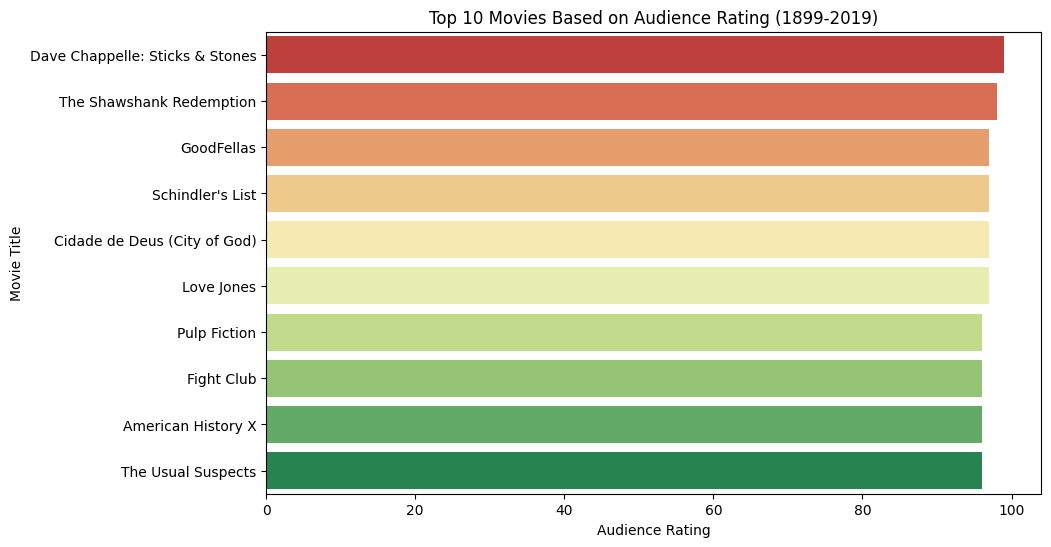

In [55]:
# Bar chart for top 10 movies based on audience rating
plt.figure(figsize=(10,6))
sns.barplot(data=df_sorted_audience.head(10), x='audience_rating', y='movie_title', 
            palette="RdYlGn")
plt.title('Top 10 Movies Based on Audience Rating (1899-2019)')
plt.xlabel('Audience Rating')
plt.ylabel('Movie Title')
plt.show()

**Insight** :  
- From the chart above, I got the **top 10 movies released between 1989 and 2019 with a minimum audience rating count of 25,000 people.**  
- It can be seen that the movie titled '**Dave Chappelle: Stick & Stones**' is ranked first, followed by **The Shawshank Redemption**.  
- These movies **can be recommended to my client for purchase or rental.**  
- If you want to look for more options, you can change the number to top 20, 50, 100, and so on.


In [56]:
# Display the top 10 movies highly rated by critics
df_sorted_critics.head(10)

,movie_title,tomatometer_rating,tomatometer_count
10899,Paddington 2,100,235
8825,Leave No Trace,100,220
15415,Toy Story 2,100,169
9462,Man on Wire,100,158
13474,Taxi to the Dark Side,100,93
15414,Toy Story,100,88
8564,Knock Down the House,100,86
6577,GETT: The Trial of Viviane...,100,77
5094,Deliver Us from Evil,100,72
16022,Waste Land,100,71


C:\Users\maruf\AppData\Local\Temp\ipykernel_1532\158192904.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_sorted_critics.head(10), x='tomatometer_rating', y='movie_title',


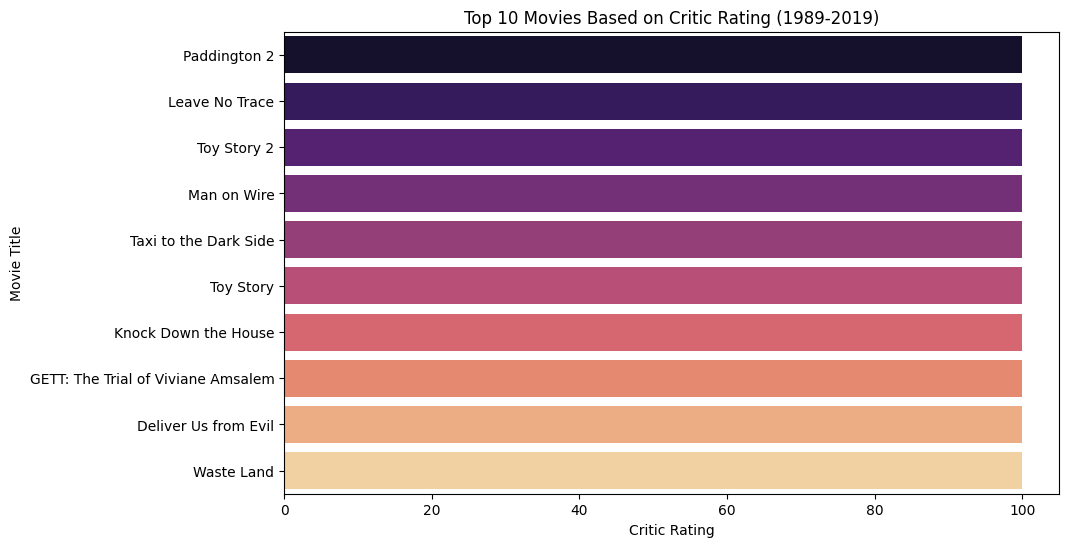

In [57]:
# Bar chart for top 10 movies based on tomatometer rating or critic rating
plt.figure(figsize=(10,6))
sns.barplot(data=df_sorted_critics.head(10), x='tomatometer_rating', y='movie_title', 
            palette='magma')
plt.title('Top 10 Movies Based on Critic Rating (1989-2019)')
plt.xlabel('Critic Rating')
plt.ylabel('Movie Title')
plt.show()

**Insight** :  
- From the chart above, I obtained the **top 10 movies with the best critic ratings from 1899 to 2019**.  
- It can be seen that the movie '**Paddington 2**' has the **highest critic rating based on the number of critics**, with a total of 235 critics.  
- Followed by **Leave No Trace** and **Toy Story 2** at the second and third positions respectively.  
- This data can be recommended to my client, which is an **Online Streaming Platform for purchase or rental**.

## 5.2 Which studio produced the most films from 1989 to 2019?

In [58]:
# Count the number of films produced by each studio (excluding 'Unknown')
filtered_df1 = df_v3[df_v3['studio_name'] != 'Unknown']
studio_counts = filtered_df1['studio_name'].value_counts()
studio_counts.head(10)

studio_name
IFC Films                           395
Warner Bros. Pictures               375
Universal Pictures                  357
20th Century Fox                    337
Sony Pictures Home Entertainment    275
Netflix                             274
Paramount Pictures                  266
Sony Pictures Classics              258
Magnolia Pictures                   250
Warner Home Video                   180
Name: count, dtype: int64

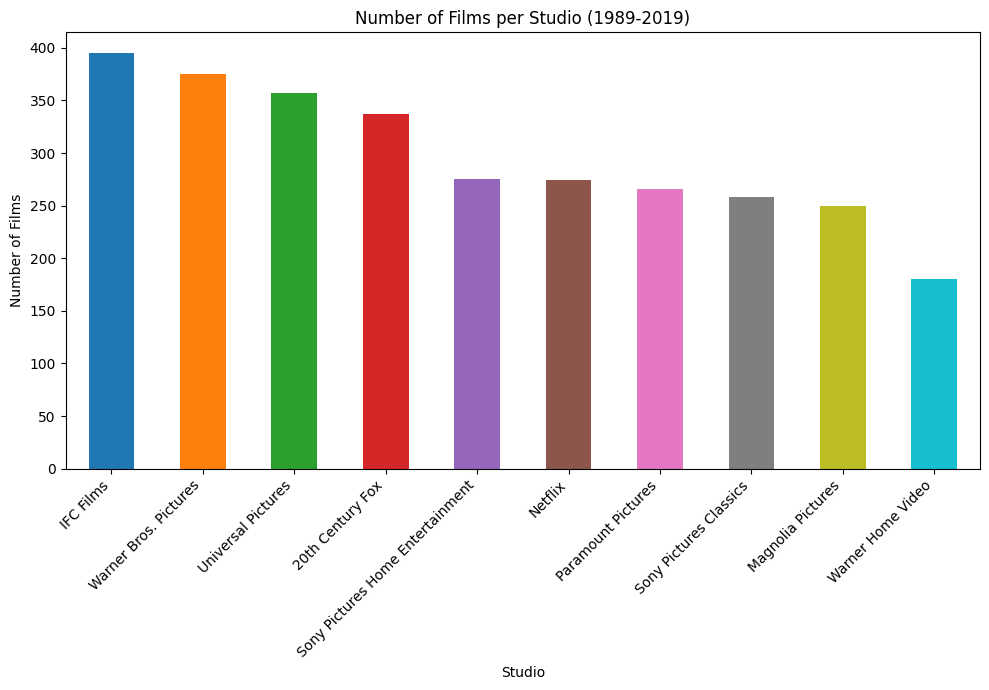

In [59]:
# Bar chart showing number of films produced by each studio excluding "Unknown"
plt.figure(figsize=(10, 7))
studio_counts.head(10).plot(kind='bar', color=sns.color_palette("tab10"))

plt.title('Number of Films per Studio (1989-2019)')
plt.xlabel('Studio')
plt.ylabel('Number of Films')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

**Insight**:  
- From the chart and table above, I obtained the **top 10 film studios with the highest number of films produced**, which can serve as a reference for purchasing films based on the studio name. This is useful for people whose preference is oriented by the film studio, for example, many will watch or follow movies from **Marvel Studios**.  
- It is also visible from the chart that **'IFC Films' has produced the most films** compared to other studios.  
- Followed by **'Warner Bros. Pictures' and Universal Pictures** at the second and third positions.  
- On average, these studios have produced more than 200 films each, except for **Warner Home Video**, which produced around 180 films.

## 5.3 What is the trend of movie genres from 1989 to 2019?

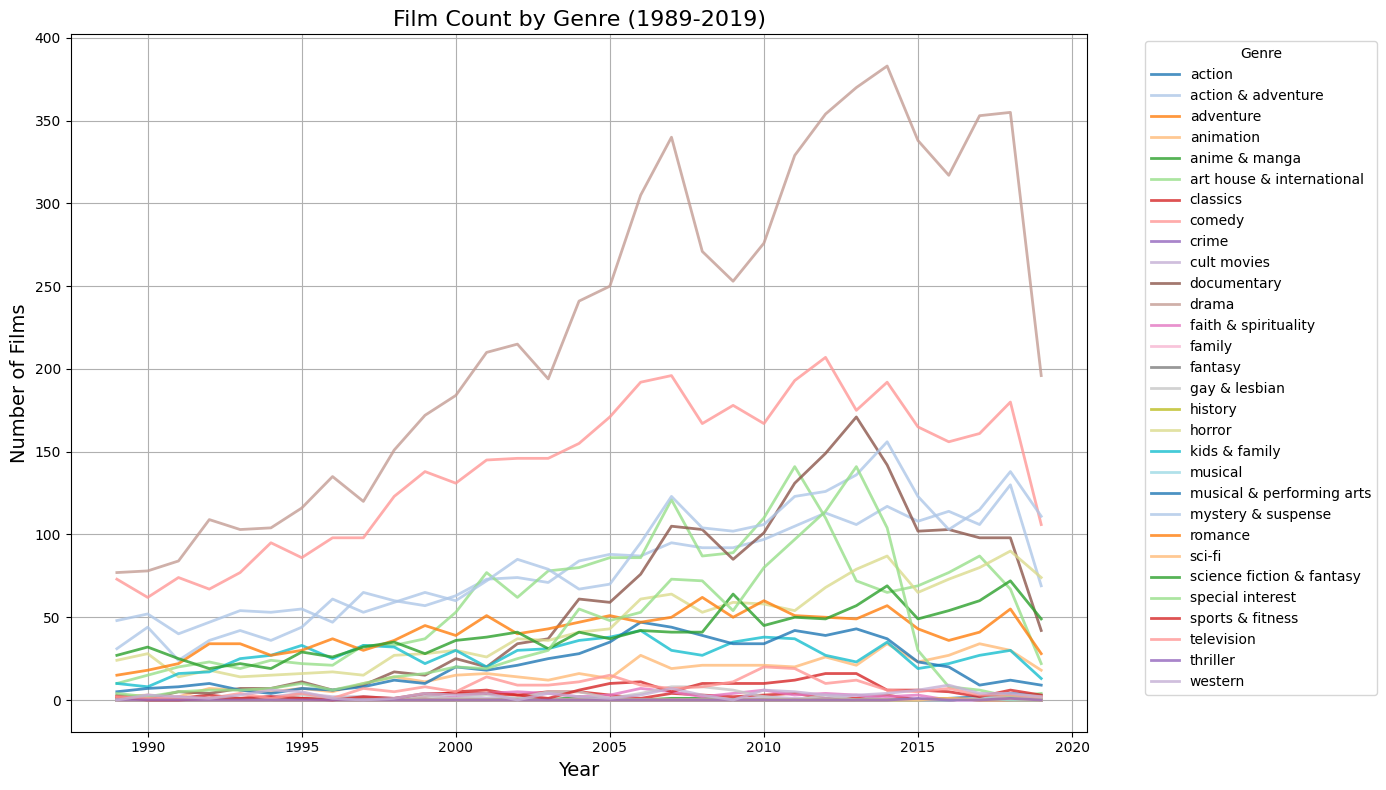

In [60]:
# Count the number of films by genre per year
film_counts = df_genre_exploded.groupby(['release_year', 'genre']).size().unstack(fill_value=0)

# Ensure all years from 1989 to 2019 are included
all_years = pd.Index(range(1989, 2020))
film_counts = film_counts.reindex(all_years, fill_value=0)

# Plot line chart
plt.figure(figsize=(14, 8))

palette = sns.color_palette("tab20", n_colors=len(film_counts.columns))

for i, genre in enumerate(film_counts.columns):
    plt.plot(film_counts.index, film_counts[genre], label=genre, 
             linewidth=2, alpha=0.8, color=palette[i])

plt.title('Film Count by Genre (1989-2019)', fontsize=16)
plt.xlabel('Year', fontsize=14)
plt.ylabel('Number of Films', fontsize=14)
plt.legend(title='Genre', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.tight_layout()
plt.show()

**Insight**:  
- From the line chart above, it can be concluded that the **drama genre has been steadily increasing**, although there was a sharp drop around 2018, possibly due to changes in market preferences. Overall, this genre showed consistent growth since 1989.  
- The **comedy genre ranks second**, exhibiting fluctuations with rises and falls, including a decline from 2018 to 2019.  
- **Action and adventure genres** are also popular, though less so compared to drama and comedy.  
- The **documentary genre experienced a sharp increase** during certain periods, roughly between 2009 and 2013.  
- Overall, the **average production of film genres declined during 2018-2019**.

## 5.4 Does the director's name affect audience and critic ratings? And why could that happen?

I will examine the relationship between the director and both audience_rating and tomatometer_rating. Before deciding on the method to use, I will check the skewness of tomatometer_rating and audience_rating.

In [61]:
# Check skewness of tomatometer_rating and audience_rating
skewness_tr = df_v3['tomatometer_rating'].skew()
skewness_ar = df_v3['audience_rating'].skew()

print(f"Skewness tomatometer_rating : {skewness_tr}")
print(f"Skewness audience_rating : {skewness_ar}")

Skewness tomatometer_rating : -0.30262816202526377
Skewness audience_rating : -0.25564984536318025


**Insight**:  
- It appears that both audience and critic ratings have a **left-skewed distribution**.  
- Although the skewness is not very large, I will use the **Kruskal-Wallis test** to examine the correlation between the audience_rating and directors, and between the tomatometer_rating and directors, because the directors column contains many different director names, not just two.

**Hypothesis** :  
H1: There is at least one significant difference in the median audience_rating between groups based on directors.
Meaning, the director's name has a significant effect on audience ratings.

H0: There is no significant difference in the median audience_rating between groups based on directors.
Meaning, the director's name does not significantly affect audience ratings.

In [62]:
# Kruskal-Wallis test for audience_rating grouped by directors
groups = [df_v3[df_v3['directors'] == director]['audience_rating'] for director in df_v3['directors'].unique()]

stat, p_value = kruskal(*groups)

print(f"Kruskal-Wallis Statistic: {stat}")
print(f"P-value: {p_value}")

if p_value < 0.05:
    print("There is at least one significant difference in the median audience_rating between groups based on directors.")
else:
    print("There is no significant difference in the median audience_rating between groups based on directors.")

Kruskal-Wallis Statistic: 8899.072074147392
P-value: 1.223715094808582e-30
There is at least one significant difference in the median audience_rating between groups based on directors.


**Insight:**  
- The null hypothesis (H0) is rejected because the p-value is less than 0.05, indicating that there is at least one significant difference in the median audience_rating between groups based on directors.  
- This means that the director's name influences audience ratings.  
- This could happen due to differences in directing styles, as each director likely has their own unique art style.  
- It could also be because some directors are more famous than others.  
- Additionally, certain directors usually have different preferences for actors, writers, and crew members.

----------------------------------------------------------------------------------------------------------------------------------------------------

**Hypothesis:**  
- H1: There is at least one significant difference in the median tomatometer_rating between groups based on directors.  
  Meaning, the director's name has a significant effect on critic ratings.  

- H0: There is no significant difference in the median tomatometer_rating between groups based on directors.  
  Meaning, the director's name does not significantly affect critic ratings.

In [63]:
# Kruskal-Wallis test for tomatometer_rating grouped by directors
groups = [df_v3[df_v3['directors'] == director]['tomatometer_rating'] for director in df_v3['directors'].unique()]

stat, p_value = kruskal(*groups)

print(f"Kruskal-Wallis Statistic: {stat}")
print(f"P-value: {p_value}")

if p_value < 0.05:
    print("There is at least one significant difference in the median tomatometer_rating between groups based on directors.")
else:
    print("There is no significant difference in the median tomatometer_rating between groups based on directors.")

Kruskal-Wallis Statistic: 9748.076647922773
P-value: 1.971803136566213e-68
There is at least one significant difference in the median tomatometer_rating between groups based on directors.


**Insight:**  
- Since the p-value is less than 0.05, H0 is rejected, which means there is at least one significant difference in the median tomatometer_rating between groups based on directors.  
- This means that the director's name also influences critic ratings.  
- It appears that some directors have more outstanding films compared to others.  
- These differences may be due to experience and the choice of crew, writers, and cast.

## 5.5 Who is the director with the highest average film rating?

After observing the relationship between directors and audience_rating/tomatometer_rating, looking at films based on directors' preferences becomes more relevant.

In [64]:
# Calculate average audience rating and total audience count by director
director_stats_aud = df_v3.groupby('directors').agg({
    'audience_rating': 'mean',
    'audience_count': 'sum'
}).reset_index()

director_stats_aud = director_stats_aud[director_stats_aud['audience_count'] >= 25000]

director_stats_aud = director_stats_aud.sort_values(['audience_rating', 'audience_count'], ascending=False)

director_stats_aud.head(20)

,directors,audience_rating,audience_count
6545,Stan Lathan,99.000000,39456.0
2313,"Fernando Meirelles, Kátia ...",97.000000,251959.0
6866,Theodore Witcher,97.000000,25700.0
3788,Josh Cooley,94.000000,53114.0
4258,"Lee Unkrich, Adrian Molina",94.000000,26889.0
4369,Louie Psihoyos,94.000000,25728.0
6111,"Roger Allers, Rob Minkoff",93.000000,1269333.0
7299,Wolfgang Becker,93.000000,55833.0
3845,Juan José Campanella,93.000000,28477.0
1143,Charles Ferguson (III),92.500000,37730.0


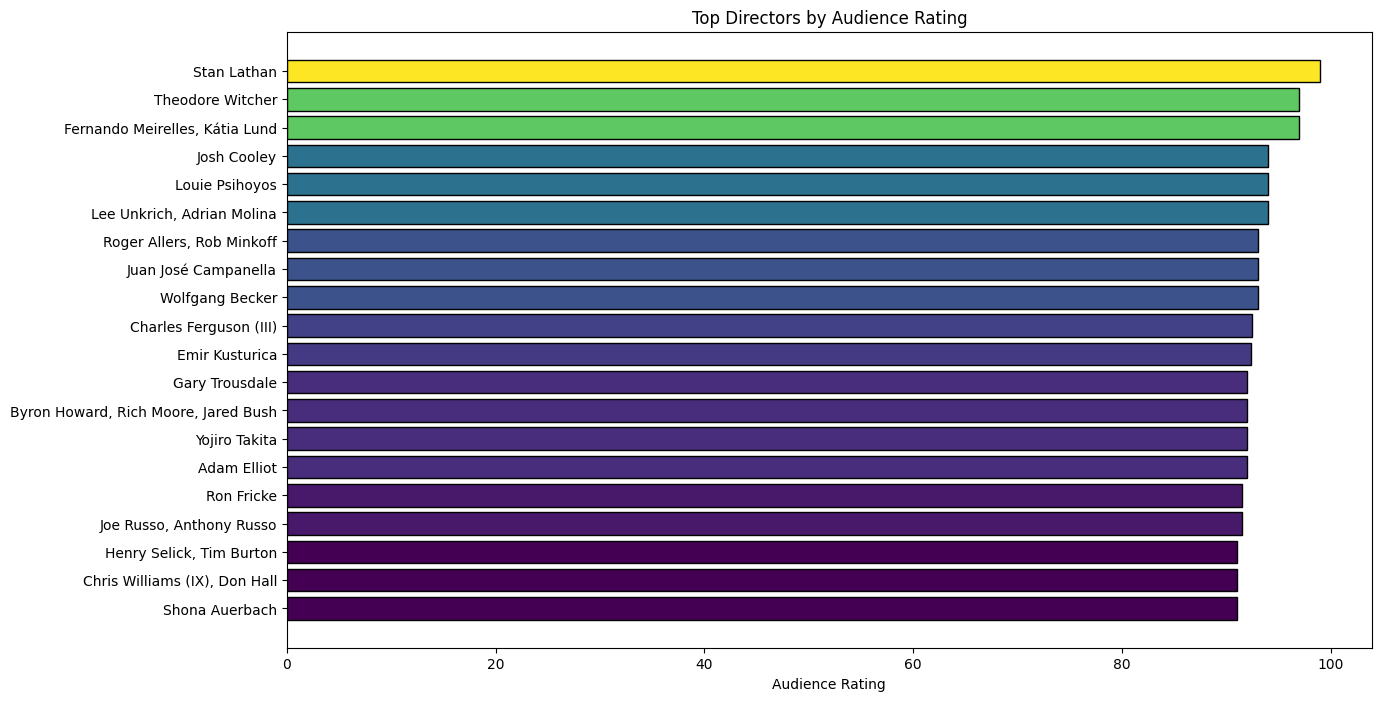

In [65]:
# Chart of top directors with the highest rating based on audience
top_directors_byAud = director_stats_aud.sort_values('audience_rating', ascending=False).head(20)
ratings = top_directors_byAud['audience_rating']
names = top_directors_byAud['directors']

# Normalize ratings between 0 and 1
norm_ratings = (ratings - ratings.min()) / (ratings.max() - ratings.min())

# Use the viridis colormap for gradient colors
colors = plt.cm.viridis(norm_ratings)

plt.figure(figsize=(14, 8))
plt.barh(names, ratings, color=colors, edgecolor='black')
plt.gca().invert_yaxis()
plt.xlabel('Audience Rating')
plt.title('Top Directors by Audience Rating')
plt.show()

**Insight**
- Here, I found **20 directors with the highest movie ratings**.
- **Stan Lathan** is the director with the **highest rated film**, followed by **Theodore Witcher** in second place, and **Fernando Meirelles** and **Katia Lund** tied in third.
- Interestingly, the **Russo Brothers (Joe Russo and Anthony Russo)**, directors of *Avengers: Endgame*, also made it into the top 20, ranking 17th.
- This can serve as a **recommendation for our client**, to base suggestions **not only on film titles but also on top directors**.

In [66]:
#Viewing directors with the highest movie ratings based on critics' ratings
director_stats_crit = df_v3.groupby('directors').agg({
    'tomatometer_rating': 'mean',
    'tomatometer_count': 'sum'
}).reset_index()

director_stats_crit = director_stats_crit[director_stats_crit['tomatometer_count'] >= 50]

director_stats_crit = director_stats_crit.sort_values(['tomatometer_rating', 'tomatometer_count'], ascending=False)

director_stats_crit.head(20)

,directors,tomatometer_rating,tomatometer_count
3544,John Lasseter,100.0,257
5758,Rachel Lears,100.0,86
6472,"Shlomi Elkabetz, Ronit Elk...",100.0,77
4395,"Lucy Walker, João Jardim, ...",100.0,71
3234,Jehane Noujaim,100.0,68
2711,Havana Marking,100.0,62
6278,Sandi Tan,100.0,61
4343,Lixin Fan,100.0,54
815,Bo Burnham,99.5,317
2631,Greta Gerwig,99.0,379


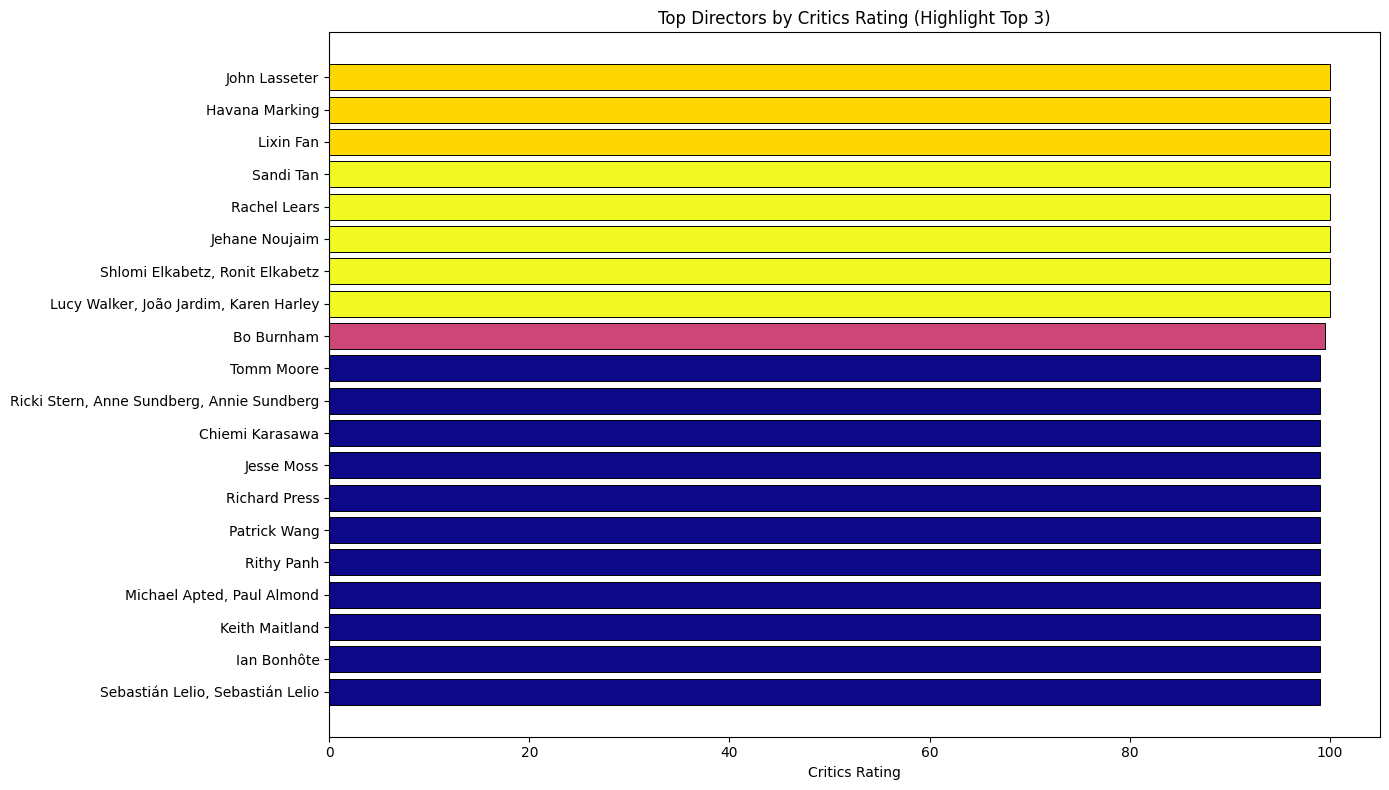

In [67]:
# Diagram of the top 10 directors with the highest ratings based on critics' ratings
top_directors_byCrit = director_stats_crit.sort_values('tomatometer_rating', ascending=False).head(20)
ratings = top_directors_byCrit['tomatometer_rating']
names = top_directors_byCrit['directors']

# Normalize ratings for colormap
norm_ratings = (ratings - ratings.min()) / (ratings.max() - ratings.min())

# Base colors with plasma colormap
base_colors = plt.cm.plasma(norm_ratings)

# Special highlight colors for top 3
colors = []
for i in range(len(ratings)):
    if i < 3:  # highlight top 3 with golden color
        colors.append('#FFD700')  # gold color
    else:
        colors.append(base_colors[i])

plt.figure(figsize=(14, 8))
plt.barh(names, ratings, color=colors, edgecolor='black', linewidth=0.7)
plt.gca().invert_yaxis()
plt.xlabel('Critics Rating')
plt.title('Top Directors by Critics Rating (Highlight Top 3)')
plt.tight_layout()
plt.show()

**Insight**

- Here, I have obtained the **top 20 directors based on critics' ratings**.  
- **John Lasseter is ranked first**, while those ranked from second to eighth have the same rating, differentiated only by the number of critics who rated them.  
- This can serve as a **recommendation for purchasing or renting films based on top directors**.

## 5.6 What are the average, mode, and median film durations from 1989 to 2019?

### a. Calculate the average and median film durations

In [68]:
# Check average film duration overall
average_film_duration = df_v3['runtime_in_minutes'].mean()
print(f'Average film duration from 1989 to 2019 is: {average_film_duration:.2f}')

# Check median film duration overall
median_film_duration = df_v3['runtime_in_minutes'].median()
print(f'Median film duration from 1989 to 2019 is: {median_film_duration:.2f}')

Average film duration from 1989 to 2019 is: 101.50
Median film duration from 1989 to 2019 is: 98.00


**Insight**:  
- It can be seen that the **median** of the movie duration is **98 minutes**  
- It can be concluded that the **average** movie duration watched is **101 minutes**  
- Considering the **mean** and **median** are not significantly different, it indicates that there are **no outliers** in the movie duration column

## 5.7 Does short or long movie duration affect viewer ratings?

**Hypotheses**

- H0 = There is **no significant relationship** between movie duration (short or long) and viewer ratings  
- H1 = There **is a significant relationship** between movie duration (short or long) and viewer ratings

Here, I will examine whether there is a relationship between movie duration and viewer ratings by calculating the **P-Value** and using the **Spearman method** for comparison.

In [69]:
# Filter by audience count greater than 25,000 to make the analysis more reasonable
filtered_duration = df_v3[df_v3['audience_count'] >= 25000].copy()

# Set a threshold to clearly distinguish between long and short movies
threshold = 90

# Add a new column for duration category
filtered_duration['duration_category'] = filtered_duration['runtime_in_minutes'].apply(lambda x: 'Short' if x < threshold else 'Long')

# Calculate Spearman correlation and its p-value
corr_spearman, p_value_spearman = spearmanr(filtered_duration['runtime_in_minutes'], filtered_duration['audience_rating'])

print("Spearman Correlation:", corr_spearman)
print("P-value:", p_value_spearman)

Spearman Correlation: 0.3423154116756649
P-value: 4.0633588787220995e-102


**Insight**:  
1. **Spearman Correlation: 0.34**  
   - A value of **0.34** indicates a **moderate positive relationship**, but movie duration is **not the only factor** affecting viewer ratings  
   - **H1 is accepted**, thus **H0 is rejected**  
2. **P-value: 5.1428991179714946e-102**  
   - This indicates that the relationship is **not due to chance**, so there **is indeed a relationship**, although small  
   - **Longer movie durations** can be associated with **higher audience ratings**

After examining the correlation, I will assess the strength of the relationship using the **Spearman correlation coefficient**.

In [70]:
# Assessing the strength of the relationship between runtime in minutes and viewer ratings

# Calculate Spearman correlation between movie duration and audience_rating
rho, p_value = stats.spearmanr(df_v3['runtime_in_minutes'], df_v3['audience_rating'])

print(f"Spearman Correlation: rho = {rho:.4f}, p-value = {p_value:.4g}")

if abs(rho) < 0.2:
    print(f"The relationship between audience_rating and movie duration is very weak or almost nonexistent ({rho:.4f})")
elif 0.2 <= abs(rho) < 0.4:
    print(f"The relationship between audience_rating and movie duration is weak ({rho:.4f})")
elif 0.4 <= abs(rho) < 0.6:
    print(f"The relationship between audience_rating and movie duration is moderate ({rho:.4f})")
elif 0.6 <= abs(rho) < 0.8:
    print(f"The relationship between audience_rating and movie duration is strong ({rho:.4f})")
else:  # 0.8 <= abs(rho) <= 1
    print(f"The relationship between audience_rating and movie duration is very strong ({rho:.4f})")

Spearman Correlation: rho = 0.1947, p-value = 3.088e-113
The relationship between audience_rating and movie duration is very weak or almost nonexistent (0.1947)


**Insight**:  
- Based on the **rho result** above, it can be concluded that the **strength of the relationship** between **duration_minutes** and **audience_rating** is **very weak**

## 5.8 Do cast names influence audience ratings and critic ratings?

**Hypothesis 1**

H0: There is **no significant difference** in the **median tomatometer_rating** between cast groups  
H1: There **is a significant difference** in the **median tomatometer_rating** between cast groups  

**Hypothesis 2**

H0: There is **no significant difference** in the **median audience_rating** between cast groups  
H1: There **is a significant difference** in the **median audience_rating** between cast groups

In [71]:
# Prepare rating data per cast group for tomatometer_rating
groups_tomatometer = [group['tomatometer_rating'].values for _, group in df_v3.groupby('cast')]

# Prepare rating data per cast group for audience_rating
groups_audience = [group['audience_rating'].values for _, group in df_v3.groupby('cast')]

# Kruskal-Wallis test for tomatometer_rating based on cast
stat_tomato, p_tomato = stats.kruskal(*groups_tomatometer)

# Kruskal-Wallis test for audience_rating based on cast
stat_audience, p_audience = stats.kruskal(*groups_audience)

print(f"Kruskal-Wallis test for Tomatometer Rating:\nH = {stat_tomato:.4f}, p-value = {p_tomato:.4e}")
print(f"Kruskal-Wallis test for Audience Rating:\nH = {stat_audience:.4f}, p-value = {p_audience:.4e}")

# Interpretation of results
if p_tomato < 0.05:
    print("There is a significant difference in the median tomatometer_rating between cast groups (reject H0).")
else:
    print("No significant difference in the median tomatometer_rating between cast groups (fail to reject H0).")

if p_audience < 0.05:
    print("There is a significant difference in the median audience_rating between cast groups (reject H0).")
else:
    print("No significant difference in the median audience_rating between cast groups (fail to reject H0).")

Kruskal-Wallis test for Tomatometer Rating:
H = 13205.8054, p-value = 4.1597e-01
Kruskal-Wallis test for Audience Rating:
H = 13189.1245, p-value = 4.5638e-01
No significant difference in the median tomatometer_rating between cast groups (fail to reject H0).
No significant difference in the median audience_rating between cast groups (fail to reject H0).


**Insight**:  
- From both **Kruskal-Wallis tests** above, there is **no significant relationship** between cast and tomatometer_rating, as well as between cast and audience_rating. Therefore, **H0 in both hypotheses is accepted**  
- Hence, there is **no need** to explore **movie recommendations based on the combination of rating data, director, and popular cast**

# **BAB 6 - EXPORT DATAFRAME**

In [66]:
# Export cleaned files to Excel for dashboard creation
df_v3.to_excel('Rotten Tomatoes Movies Clean.xlsx', index=False)

df_genre_exploded.to_excel('Genre_Table.xlsx', index=False)

# **BAB 7 - CONCLUSION**

From this analysis, it can be concluded that the objective of identifying **movie preferences for streaming platforms** has been achieved. The following points have been addressed:

1. **Critic and audience ratings** can serve as the **primary indicators** when selecting movies for rental or purchase by streaming platforms.  
2. **Movie duration** has a **positive correlation** with **audience ratings**, although it is not very strong.  
3. **Directors** have a **significant influence** on movie ratings, from both **critics** and **audiences**.  
4. Certain **genres** show an **increasing trend in popularity** over time and should be considered in **content acquisition strategies**.  
5. There is **no relationship** between **cast names** and **audience ratings**; therefore, having a column like **views / number of viewers per film** may serve as an additional reference for recommendations.  
6. Selecting **high-quality and appropriate films** has the potential to **increase customer loyalty** toward the streaming platform.